# Regularized Poisson MLEM Deep Unfolding Playground

This notebook is a compact playground for reconstruction from Poisson measurements with a deterministic background term:

$$
y \sim \mathrm{Poisson}(Ax + b).
$$

It compares classical hand tuned regularized MLEM against unfolded MLEM variants that learn per-layer regularization, denominator corrections, and, in the mismatched setting, the objective parameters themselves.


## Imports and Device Setup

The notebook is designed to run in Google Colab or locally. It uses dense PyTorch tensors for the unfolded models so the code stays easy to read; the synthetic system matrix is generated as a SciPy sparse matrix and then converted to dense tensors for training.


In [82]:
import json
import math
import os
import random
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from IPython.display import display
except Exception:
    display = print


def set_random_seeds(seed: int, use_cuda: bool = False) -> None:
    """Set NumPy, Python, and PyTorch seeds."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if use_cuda and torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def select_torch_device():
    """Use CUDA when it is available and the installed PyTorch build can run it."""
    if torch.cuda.is_available():
        try:
            major, minor = torch.cuda.get_device_capability()
            cap_tag = f"sm_{major}{minor}"
            arch_list = []
            if hasattr(torch.cuda, "get_arch_list"):
                arch_list = torch.cuda.get_arch_list()
            if arch_list and cap_tag not in arch_list:
                print(f"CUDA device capability {cap_tag} is not in this PyTorch build's arch list {arch_list}; falling back to CPU.")
                return torch.device("cpu")
            probe = torch.ones(1, device="cuda")
            _ = probe + 1.0
            torch.cuda.synchronize()
            return torch.device("cuda")
        except Exception as exc:
            print("CUDA detected but not usable by this PyTorch build; falling back to CPU.")
            print("CUDA check error:", exc)
    return torch.device("cpu")


torch.set_default_dtype(torch.float32)
device = select_torch_device()
set_random_seeds(123, use_cuda=(device.type == "cuda"))
print("Using device:", device)


def make_jet_zero_black_cmap():
    """Create a jet colormap where exact zero-valued pixels render as black."""
    base = plt.get_cmap("jet")
    colors = base(np.linspace(0.0, 1.0, 256))
    colors[0] = np.array([0.0, 0.0, 0.0, 1.0])
    cmap = matplotlib.colors.ListedColormap(colors, name="jet_zero_black")
    cmap.set_bad("black")
    cmap.set_under("black")
    return cmap


HOTSPOT_CMAP = make_jet_zero_black_cmap()


def mask_exact_zeros_for_black(values):
    """Mask exact zero pixels so matplotlib draws them black via HOTSPOT_CMAP.set_bad."""
    arr = np.asarray(values)
    return np.ma.masked_where(np.abs(arr) == 0.0, arr)


Using device: cuda


## Configuration

The base configuration keeps the full values requested for the playground. `quick_run=True` applies small overrides so all cells can run top to bottom quickly in a fresh Colab session. Set `quick_run=False` when you want the larger experiment.


In [83]:
SUPPORTED_RECONSTRUCTION_LOSS_ALIASES = {
    "mse": "mse",
    "mean_squared_error": "mse",
    "fro": "frobenius",
    "frobenius": "frobenius",
    "frobenious": "frobenius",
    "frobinious": "frobenius",
}


def normalize_reconstruction_loss_name(loss_name):
    """Normalize the user-selected supervised reconstruction loss name."""
    key = str(loss_name).strip().lower()
    if key not in SUPPORTED_RECONSTRUCTION_LOSS_ALIASES:
        choices = sorted(set(SUPPORTED_RECONSTRUCTION_LOSS_ALIASES.values()))
        raise ValueError(f"Unknown reconstruction_loss={loss_name!r}; choose one of {choices}.")
    return SUPPORTED_RECONSTRUCTION_LOSS_ALIASES[key]


@dataclass
class Config:
    # Core synthetic problem
    seed: int = 123  # Master random seed for reproducible data, models, and training.
    img_size: int = 32  # Side length of the square image grid.
    num_pixels: int = 32 * 32  # Flattened image dimension; finalized from img_size below.
    num_measurements: int = 500  # Number of Poisson measurement bins, i.e. rows of A.
    num_hotspots: int = 20  # Number of Gaussian hot spots in each synthetic ground truth image.
    hotspot_sigma_range: tuple = (0.93, 0.93)  # Min/max Gaussian width used for random hot spots.
    A_sparsity: float = 0.97  # Fraction of entries in A that should be zero; higher means fewer links.
    count_scale: float = 20000.0  # Total image intensity before generating Poisson counts.
    background_level: float = 0.25  # Constant deterministic background b added to every measurement bin.

    # Classical and unfolded reconstruction
    regularization_gamma: float = 1e-4  # Hand tuned gamma used by the classical regularized MLEM baseline.
    regularization_gamma_init: float = 1e-4  # Initial gamma value for learned per-layer regularization.
    gamma_min: float = 0  # Small positive lower bound for learned gamma values.
    gamma_max: float = np.inf  # Upper clamp for learned gamma values to avoid unstable updates.
    num_mlem_iters: int = 100  # Number of iterations for the classical MLEM wrapper.
    num_unfolded_layers: int = 10  # Number of unfolded EM layers in trainable architectures.

    # Dataset and optimization
    num_train: int = 2500  # Number of synthetic training samples.
    num_val: int = 500  # Number of validation samples used during training.
    num_test: int = 100  # Number of held-out samples for final comparisons and plots.
    batch_size: int = 64  # Mini-batch size for DataLoaders.
    num_epochs: int = 50  # General epoch budget placeholder for quick experiments.
    learning_rate: float = 1e-3  # Adam learning rate for sequential layer-wise training.
    reconstruction_loss: str = "frobenius"  # Supervised train/validation loss: "mse" or "frobenius".

    # Two stage training schedule
    sequential_train: bool = True  # Enable layer-wise per-layer seq training before interleaved e2e passes.
    sequential_epochs_per_stage: int = 50  # Epochs to train at each sequential active-layer stage.
    end_to_end_epochs: int = 100  # Epochs for each interleaved e2e pass after sequential training at a layer.
    end_to_end_learning_rate: float = 5e-3  # Adam learning rate for end-to-end fine tuning.
    freeze_previous_layers_during_sequential: bool = True  # Legacy flag; seq/e2e trainability is now controlled by enable_single_layer/enable_layers.

    # Mismatch experiment controls
    run_non_mismatched_experiment: bool = True  # Run Experiment 1 with A_recon=A_true and b_recon=b_true.
    run_mismatched_experiment: bool = True  # Run Experiment 2 with data from true parameters and reconstruction from nominal ones.
    A_mismatch_mode: str = "multiplicative_scale"  # Rule used to perturb A_true into A_nominal.
    A_mismatch_scale_std: float = 0.25  # Standard deviation of log-normal multiplicative perturbations on nonzero A entries.
    A_mismatch_drop_probability: float = 0.7  # Probability of dropping a nonzero nominal A entry after perturbation.
    b_mismatch_mode: str = "scale_and_offset"  # Rule used to perturb b_true into b_nominal.
    b_nominal_scale: float = 0.7  # Multiplicative scale applied to b_true for mismatched reconstruction.
    b_nominal_offset: float = 0.1  # Additive offset applied to b_true for mismatched reconstruction.

    # Architecture controls
    learn_A_preserve_sparsity: bool = True  # Keep zero entries of A fixed when learning A_eff.
    learn_b: bool = True  # Learn b_eff in the learned-objective architecture.
    correction_scale_init: float = 1e-3  # Small multiplier for the denominator correction CNN output.
    run_only_classical_MLEM: bool = False  # Debug switch to evaluate only the non-trainable classical baseline.
    include_learned_objective_in_non_mismatch: bool = False  # Also train learned-objective model in Experiment 1 as a sanity check.

    # Final cell controls
    EXPERIMENT_NAME: str = "non_mismatched"  # Default experiment name for single-experiment workflows.
    MODEL_NAME: str = "denominator_correction" # "learned_gamma"  # Model to run when RUN_ALL_MODELS_IN_EXPERIMENT is False.
    RUN_ALL_MODELS_IN_EXPERIMENT: bool = True  # If true, train/evaluate every relevant model in each experiment.

    # Practical run controls
    quick_run: bool = False  # Use small dimensions and short schedules for fast smoke tests.
    save_checkpoints: bool = False  # Save trained model checkpoints under trained_models/ when enabled.
    eps: float = 1e-8  # Numerical stabilizer for divisions, logs, rates, and positive parameterizations.


def finalize_config(cfg: Config) -> Config:
    """Keep dependent fields consistent after manual edits."""
    return replace(
        cfg,
        num_pixels=cfg.img_size * cfg.img_size,
        reconstruction_loss=normalize_reconstruction_loss_name(cfg.reconstruction_loss),
    )


BASE_CONFIG = Config()
config = BASE_CONFIG

if config.quick_run:
    config = replace(
        config,
        img_size=32,
        num_pixels=config.img_size * config.img_size,
        num_measurements=256,
        count_scale=500.0,
        num_train=250,
        num_val=50,
        num_test=10,
        num_mlem_iters=40,
        num_unfolded_layers=10,
        batch_size=10,
        num_epochs=100,
        sequential_epochs_per_stage=50,
        end_to_end_epochs=100,
    )

config = finalize_config(config)

# Editable model selection controls.
EXPERIMENT_NAME = config.EXPERIMENT_NAME  # "non_mismatched" or "mismatched"
MODEL_NAME = config.MODEL_NAME            # "classical_regularized", "learned_gamma", "denominator_correction", "learned_objective"
RUN_ALL_MODELS_IN_EXPERIMENT = config.RUN_ALL_MODELS_IN_EXPERIMENT
config = replace(
    config,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    MODEL_NAME=MODEL_NAME,
    RUN_ALL_MODELS_IN_EXPERIMENT=RUN_ALL_MODELS_IN_EXPERIMENT,
)

print(json.dumps(asdict(config), indent=2, default=str))



{
  "seed": 123,
  "img_size": 32,
  "num_pixels": 1024,
  "num_measurements": 500,
  "num_hotspots": 20,
  "hotspot_sigma_range": [
    0.93,
    0.93
  ],
  "A_sparsity": 0.97,
  "count_scale": 20000.0,
  "background_level": 0.25,
  "regularization_gamma": 0.0001,
  "regularization_gamma_init": 0.0001,
  "gamma_min": 0,
  "gamma_max": Infinity,
  "num_mlem_iters": 100,
  "num_unfolded_layers": 10,
  "num_train": 2500,
  "num_val": 500,
  "num_test": 100,
  "batch_size": 64,
  "num_epochs": 50,
  "learning_rate": 0.001,
  "reconstruction_loss": "frobenius",
  "sequential_train": true,
  "sequential_epochs_per_stage": 50,
  "end_to_end_epochs": 100,
  "end_to_end_learning_rate": 0.005,
  "freeze_previous_layers_during_sequential": true,
  "run_non_mismatched_experiment": true,
  "run_mismatched_experiment": true,
  "A_mismatch_mode": "multiplicative_scale",
  "A_mismatch_scale_std": 0.25,
  "A_mismatch_drop_probability": 0.7,
  "b_mismatch_mode": "scale_and_offset",
  "b_nominal_scale"

## Synthetic Image Generator

Ground truth images are nonnegative sums of Gaussian hot spots. Each image is normalized to a fixed total intensity before Poisson measurements are drawn.


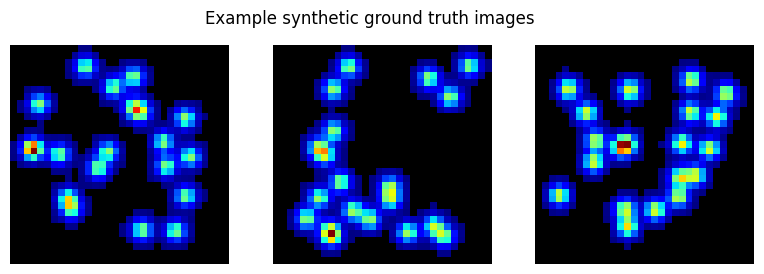

In [84]:
def generate_hotspot_image(img_size, num_hotspots, sigma_range, rng, total_intensity=1.0):
    """Generate one nonnegative image with random Gaussian hot spots."""
    yy, xx = np.mgrid[0:img_size, 0:img_size].astype(np.float32)
    image = np.zeros((img_size, img_size), dtype=np.float32)
    sigma_min, sigma_max = sigma_range

    for _ in range(num_hotspots):
        sigma = float(rng.uniform(sigma_min, sigma_max))
        margin = max(1.0, 2.5 * sigma)
        cx = float(rng.uniform(margin, img_size - 1 - margin))
        cy = float(rng.uniform(margin, img_size - 1 - margin))
        amplitude = float(rng.uniform(99, 101))
        image += amplitude * np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2))

    image = np.clip(image, 0.0, None)
    total = float(image.sum())
    if total > 0:
        image = image / total * float(total_intensity)
    return image.astype(np.float32).reshape(-1)


def preview_hotspot_images(config, n=3):
    rng = np.random.default_rng(config.seed)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3))
    if n == 1:
        axes = [axes]
    for ax in axes:
        x = generate_hotspot_image(
            config.img_size,
            config.num_hotspots,
            config.hotspot_sigma_range,
            rng,
            total_intensity=config.count_scale,
        )
        img = x.reshape(config.img_size, config.img_size)
        ax.imshow(mask_exact_zeros_for_black(img), cmap=HOTSPOT_CMAP, vmin=0.0)
        ax.set_axis_off()
    fig.suptitle("Example synthetic ground truth images")
    plt.show()


preview_hotspot_images(config, n=3)


## Sparse System Matrix and Background

The system matrix is generated as a sparse nonnegative matrix. Columns are normalized to unit sum so every pixel has comparable sensitivity under the true model. This makes the MLEM sensitivity term well conditioned while preserving a sparse measurement pattern.


In [85]:
def generate_sparse_system_matrix(num_measurements, num_pixels, sparsity, rng):
    """Generate a sparse nonnegative matrix with unit column sums."""
    generator = torch.Generator()
    generator.manual_seed(int(rng.integers(0, 2**31 - 1)))

    M, N = num_measurements, num_pixels
    A = torch.rand(M, N, generator=generator) * 2.0
    mask = torch.rand(M, N, generator=generator) > sparsity
    A = A * mask.float()

    col_sums = torch.sum(A, dim=0, keepdim=True)
    col_sums[col_sums == 0] = 1.0
    A = A / col_sums

    return sp.csr_matrix(A.numpy().astype(np.float32))


def generate_background(num_measurements, background_level):
    """Create a deterministic constant background vector b."""
    b = torch.full((num_measurements,), float(background_level))
    return b.numpy().astype(np.float32)


def generate_measurement(A, x, b, rng, eps=1e-8):
    """Generate y ~ Poisson(Ax + b)."""
    lam = np.asarray(A @ x, dtype=np.float32).reshape(-1) + b.astype(np.float32)
    lam = np.clip(lam, eps, None)
    y = rng.poisson(lam).astype(np.float32)
    return y, lam.astype(np.float32)


def create_mismatched_nominal_model(A_true, b_true, config, rng):
    """
    Create A_nominal and b_nominal used by reconstruction models when data
    are generated from A_true and b_true.
    """
    A_nominal = A_true.copy().tocsr().astype(np.float32)

    if config.A_mismatch_mode == "multiplicative_scale":
        scales = np.exp(config.A_mismatch_scale_std * rng.standard_normal(A_nominal.data.shape)).astype(np.float32)
        A_nominal.data *= scales

    drop_probability = float(config.A_mismatch_drop_probability)
    if drop_probability > 0:
        keep = rng.random(A_nominal.data.shape) >= drop_probability
        A_nominal.data *= keep.astype(np.float32)
        A_nominal.eliminate_zeros()

    if config.b_mismatch_mode == "scale_and_offset":
        b_nominal = config.b_nominal_scale * b_true + config.b_nominal_offset
    else:
        b_nominal = b_true.copy()
    b_nominal = np.clip(b_nominal, 0.0, None).astype(np.float32)
    return A_nominal.astype(np.float32).tocsr(), b_nominal


def sparse_to_torch_dense(A, device=device):
    """Convert a SciPy sparse matrix to a dense torch tensor."""
    if sp.issparse(A):
        A = A.toarray()
    return torch.as_tensor(A, dtype=torch.float32, device=device)


def vector_to_torch(v, device=device):
    return torch.as_tensor(v, dtype=torch.float32, device=device)


rng_global = np.random.default_rng(config.seed)
A_true = generate_sparse_system_matrix(config.num_measurements, config.num_pixels, config.A_sparsity, rng_global)
b_true = generate_background(config.num_measurements, config.background_level)
A_nominal = A_true.copy()
b_nominal = b_true.copy()

print("A_true shape:", A_true.shape, "nnz:", A_true.nnz, "density:", A_true.nnz / np.prod(A_true.shape))
print("b_true shape:", b_true.shape, "background range:", (float(b_true.min()), float(b_true.max())))


A_true shape: (500, 1024) nnz: 14927 density: 0.029154296875
b_true shape: (500,) background range: (0.25, 0.25)


## Dataset Utilities

Datasets are kept in memory as `(Y, X_true)` tensor pairs. The same deterministic background vector is reused for every sample in this first version, while the functions keep `b` as a vector so sample-dependent backgrounds can be added later.


In [86]:
def generate_reconstruction_dataset(A, b, config, num_samples, rng):
    """Generate tensors Y and X_true for supervised reconstruction training."""
    X = np.zeros((num_samples, config.num_pixels), dtype=np.float32)
    Y = np.zeros((num_samples, config.num_measurements), dtype=np.float32)
    rates = np.zeros_like(Y)

    for i in range(num_samples):
        x = generate_hotspot_image(
            config.img_size,
            config.num_hotspots,
            config.hotspot_sigma_range,
            rng,
            total_intensity=config.count_scale,
        )
        y, lam = generate_measurement(A, x, b, rng, eps=config.eps)
        X[i] = x
        Y[i] = y
        rates[i] = lam

    dataset = TensorDataset(torch.from_numpy(Y), torch.from_numpy(X))
    return dataset, {"X": X, "Y": Y, "rates": rates}


def create_train_val_test_datasets(A_true, b_true, config, rng):
    """Create independent train, validation, and test tensor datasets."""
    train_dataset, train_raw = generate_reconstruction_dataset(A_true, b_true, config, config.num_train, rng)
    val_dataset, val_raw = generate_reconstruction_dataset(A_true, b_true, config, config.num_val, rng)
    test_dataset, test_raw = generate_reconstruction_dataset(A_true, b_true, config, config.num_test, rng)
    return (train_dataset, val_dataset, test_dataset), {"train": train_raw, "val": val_raw, "test": test_raw}


def make_loaders(train_dataset, val_dataset, test_dataset, config):
    """Build DataLoaders for a given experiment."""
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader, test_loader


## Visualization Helpers


In [87]:
def show_image_vector(x, img_size, title=None, ax=None, cmap=None):
    """Display one flattened image vector with jet colormap and exact zeros in black."""
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))
    cmap = HOTSPOT_CMAP if cmap is None else cmap
    img = np.asarray(x).reshape(img_size, img_size)
    im = ax.imshow(mask_exact_zeros_for_black(img), cmap=cmap, vmin=0.0)
    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return im


def plot_measurement_vector(y, title="Measurement vector"):
    plt.figure(figsize=(8, 2.5))
    plt.plot(np.asarray(y).reshape(-1), lw=1)
    plt.title(title)
    plt.xlabel("measurement index")
    plt.ylabel("counts")
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_reconstruction_grid(x_true, reconstructions, img_size, title="Reconstructions"):
    """Plot ground truth, reconstructions, and error maps for one sample."""
    names = list(reconstructions.keys())
    ncols = 1 + len(names)
    fig, axes = plt.subplots(2, ncols, figsize=(3.0 * ncols, 5.5))
    axes = np.asarray(axes)

    show_image_vector(x_true, img_size, "ground truth", axes[0, 0])
    axes[1, 0].set_axis_off()
    axes[1, 0].set_title("error")

    for j, name in enumerate(names, start=1):
        x_hat = reconstructions[name]
        show_image_vector(x_hat, img_size, name, axes[0, j])
        err = np.asarray(x_hat).reshape(img_size, img_size) - np.asarray(x_true).reshape(img_size, img_size)
        axes[1, j].imshow(err, cmap="coolwarm")
        axes[1, j].set_axis_off()
        axes[1, j].set_title("error")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_reconstruction_sequence(recons, img_size, title="MLEM reconstruction sequence", max_panels=6):
    """Plot selected iterations or layers from a reconstruction trace."""
    if recons is None or len(recons) == 0:
        return
    idx = np.linspace(0, len(recons) - 1, num=min(max_panels, len(recons)), dtype=int)
    fig, axes = plt.subplots(1, len(idx), figsize=(3 * len(idx), 3))
    if len(idx) == 1:
        axes = [axes]
    for ax, i in zip(axes, idx):
        show_image_vector(recons[i], img_size, f"step {i}", ax)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_training_history(history, title="Training history", loss_label="Loss"):
    """Plot sequential and end-to-end train/validation losses."""
    if not history:
        return
    seq = history.get("sequential", {})
    e2e = history.get("end_to_end", {})
    if not seq.get("train_loss") and not e2e.get("train_loss"):
        return

    plt.figure(figsize=(7, 4))

    if seq.get("train_loss"):
        x_seq = np.arange(len(seq["train_loss"]))
        plt.plot(x_seq, seq["train_loss"], label="seq train")
        plt.plot(x_seq, seq["val_loss"], label="seq val")

    if e2e.get("train_loss"):
        offset = len(seq.get("train_loss", []))
        x_e2e = offset + np.arange(len(e2e["train_loss"]))
        plt.plot(x_e2e, e2e["train_loss"], label="e2e train")
        plt.plot(x_e2e, e2e["val_loss"], label="e2e val")

    plt.yscale("log")
    plt.xlabel("logged epoch")
    plt.ylabel(loss_label)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


def display_comparison_table(rows):
    """Display a compact metrics table."""
    if pd is not None:
        df = pd.DataFrame(rows)
        metric_cols = [
            "experiment", "model", "MSE", "PSNR", "SSIM", "relative_error",
            "total_count_error", "NLL_true", "NLL_recon", "NLL_learned",
            "R(x)", "objective_recon", "objective_learned", "layers_or_iters",
        ]
        metric_cols = [c for c in metric_cols if c in df.columns]
        display(df[metric_cols])
        return df
    for row in rows:
        print(row)
    return rows



## Regularized Poisson Objective

For a candidate image `x`, the Poisson negative log likelihood is

$$
\mathcal{L}(x;y,A,b)=\mathbf{1}^T(Ax+b)-y^T\log(Ax+b+\epsilon).
$$

The regularizer is a quadratic 4-connected neighbor penalty:

$$
R(x)=\frac{1}{2}\sum_{(i,j)\in \mathcal{N}}(x_i-x_j)^2.
$$

The split-gradient form uses `U_R(x)=d_i x_i` and `V_R(x)=sum_j x_j` over valid neighbors.


In [88]:
def numpy_neighbor_split(x, img_size):
    """Compute U_R and V_R for one flattened NumPy image."""
    img = np.asarray(x, dtype=np.float32).reshape(img_size, img_size)
    V = np.zeros_like(img)
    degree = np.zeros_like(img)

    V[1:, :] += img[:-1, :]
    degree[1:, :] += 1
    V[:-1, :] += img[1:, :]
    degree[:-1, :] += 1
    V[:, 1:] += img[:, :-1]
    degree[:, 1:] += 1
    V[:, :-1] += img[:, 1:]
    degree[:, :-1] += 1

    U = degree * img
    return U.reshape(-1), V.reshape(-1)


def numpy_quadratic_neighbor_penalty(x, img_size):
    """Compute R(x) for one flattened NumPy image."""
    img = np.asarray(x, dtype=np.float32).reshape(img_size, img_size)
    horizontal = img[:, 1:] - img[:, :-1]
    vertical = img[1:, :] - img[:-1, :]
    return 0.5 * (np.sum(horizontal ** 2) + np.sum(vertical ** 2))


def torch_neighbor_split(X, img_size):
    """
    Compute U_R(X) and V_R(X) for the quadratic neighbor penalty.
    X shape: batch_size x num_pixels.
    """
    assert X.ndim == 2, f"Expected X shape B x N, got {tuple(X.shape)}"
    X_img = X.view(X.shape[0], 1, img_size, img_size)
    neighbor_kernel = torch.tensor(
        [[0.0, 1.0, 0.0],
         [1.0, 0.0, 1.0],
         [0.0, 1.0, 0.0]],
        device=X.device,
        dtype=X.dtype,
    ).view(1, 1, 3, 3)

    V_img = F.conv2d(X_img, neighbor_kernel, padding=1)
    degree_img = F.conv2d(torch.ones_like(X_img), neighbor_kernel, padding=1)
    U_img = degree_img * X_img
    return U_img.view_as(X), V_img.view_as(X)


def torch_quadratic_neighbor_penalty(X, img_size):
    """
    Compute R(X) = 0.5 * sum of squared horizontal and vertical differences.
    Return one scalar per batch sample.
    """
    assert X.ndim == 2, f"Expected X shape B x N, got {tuple(X.shape)}"
    X_img = X.view(X.shape[0], 1, img_size, img_size)
    horizontal = X_img[:, :, :, 1:] - X_img[:, :, :, :-1]
    vertical = X_img[:, :, 1:, :] - X_img[:, :, :-1, :]
    return 0.5 * (
        horizontal.pow(2).sum(dim=(1, 2, 3)) +
        vertical.pow(2).sum(dim=(1, 2, 3))
    )


## Classical Regularized MLEM Baseline

The E-step computes the Poisson ratio. The M-step applies the split-gradient penalized multiplicative update:

$$
x_{k+1}=x_k \odot
\frac{A^T(y/(Ax_k+b+\epsilon))+\gamma V_R(x_k)}
{A^T\mathbf{1}+\gamma U_R(x_k)+\epsilon}.
$$


In [89]:
def poisson_nll_numpy(A, x, y, b, eps=1e-8):
    """Poisson negative log likelihood up to constants independent of x."""
    rate = np.asarray(A @ x, dtype=np.float32).reshape(-1) + b
    rate = np.clip(rate, eps, None)
    return float(np.sum(rate - y * np.log(rate)))


def mlem_e_step(A, x, y, b, eps=1e-8):
    """Compute ratio y / (A x + b + eps)."""
    rate = np.asarray(A @ x, dtype=np.float32).reshape(-1) + b
    rate = np.clip(rate, eps, None)
    return y / rate


def regularized_mlem_m_step(A, x, ratio, sensitivity, gamma, img_size, eps=1e-8):
    """Apply the split-gradient penalized MLEM update."""
    backproj = np.asarray(A.T @ ratio, dtype=np.float32).reshape(-1)
    U, V = numpy_neighbor_split(x, img_size)
    numerator = backproj + float(gamma) * V
    denominator = sensitivity + float(gamma) * U + eps
    x_next = x * numerator / denominator
    return np.clip(x_next, 0.0, None).astype(np.float32)


def default_x0_from_measurement(y, b, num_pixels, eps=1e-8):
    """Use a small uniform positive image initialized from total corrected counts."""
    corrected_total = max(float(np.sum(y - b)), eps)
    return np.full(num_pixels, corrected_total / num_pixels, dtype=np.float32)


def run_regularized_mlem(A, y, b, gamma, num_iters, img_size, x0=None, eps=1e-8, x_true=None):
    """Run classical background-aware regularized MLEM and return diagnostics."""
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    b = np.asarray(b, dtype=np.float32).reshape(-1)
    num_pixels = A.shape[1]
    x = default_x0_from_measurement(y, b, num_pixels, eps=eps) if x0 is None else np.asarray(x0, dtype=np.float32).copy()
    x = np.clip(x, eps, None)
    sensitivity = np.asarray(A.T @ np.ones(A.shape[0], dtype=np.float32)).reshape(-1)
    sensitivity = np.clip(sensitivity, eps, None)

    recons = [x.copy()]
    objective_history = []
    regularization_history = []
    error_history = []

    for _ in range(num_iters):
        ratio = mlem_e_step(A, x, y, b, eps=eps)
        x = regularized_mlem_m_step(A, x, ratio, sensitivity, gamma, img_size, eps=eps)
        recons.append(x.copy())
        reg = numpy_quadratic_neighbor_penalty(x, img_size)
        regularization_history.append(reg)
        objective_history.append(poisson_nll_numpy(A, x, y, b, eps=eps) + float(gamma) * reg)
        if x_true is not None:
            error_history.append(float(np.mean((x - x_true) ** 2)))

    return {
        "x": x,
        "recons": np.stack(recons, axis=0),
        "objective_history": objective_history,
        "regularization_history": regularization_history,
        "error_history": error_history,
    }


## Batched PyTorch MLEM Primitives

The unfolded models below use dense tensors:

- `Y`: batch_size x num_measurements
- `X`: batch_size x num_pixels
- `A`: num_measurements x num_pixels
- `b`: num_measurements or batch_size x num_measurements

Sparse torch kernels can be added later if larger systems require them.


In [90]:
def expand_background_for_batch(b, Y):
    """Broadcast b to the shape of Y."""
    if b.ndim == 1:
        return b.view(1, -1).to(device=Y.device, dtype=Y.dtype)
    if b.ndim == 2:
        assert b.shape == Y.shape, f"Expected b shape {tuple(Y.shape)}, got {tuple(b.shape)}"
        return b.to(device=Y.device, dtype=Y.dtype)
    raise ValueError(f"Unsupported b shape: {tuple(b.shape)}")


def initialize_x0_torch(Y, b, num_pixels, eps=1e-8):
    """Create a positive uniform initialization for a batch."""
    b_batch = expand_background_for_batch(b, Y)
    corrected_total = torch.clamp((Y - b_batch).sum(dim=1, keepdim=True), min=eps)
    return corrected_total.repeat(1, int(num_pixels)) / float(num_pixels)


def torch_mlem_e_step(A, X, Y, b, eps=1e-8):
    """Compute ratio Y / (X @ A.T + b + eps)."""
    assert X.ndim == 2 and Y.ndim == 2
    b_batch = expand_background_for_batch(b, Y)
    rate = X @ A.T + b_batch + eps
    return Y / torch.clamp(rate, min=eps)


def torch_regularized_mlem_step(A, X, Y, b, gamma, img_size, eps=1e-8):
    """
    One split-gradient regularized MLEM step.
    gamma can be a Python scalar, tensor scalar, or batch-compatible tensor.
    """
    ratio = torch_mlem_e_step(A, X, Y, b, eps=eps)
    backproj = ratio @ A
    sensitivity = torch.clamp(A.sum(dim=0).view(1, -1), min=eps)
    U, V = torch_neighbor_split(X, img_size)
    gamma_t = torch.as_tensor(gamma, dtype=X.dtype, device=X.device)
    numerator = backproj + gamma_t * V
    denominator = sensitivity + gamma_t * U + eps
    X_next = X * numerator / denominator
    return torch.clamp(X_next, min=0.0)


## Architecture 0: Classical Regularized MLEM Wrapper


In [91]:
class ClassicalRegularizedMLEM(nn.Module):
    """Non-trainable wrapper around fixed regularized MLEM iterations."""

    def __init__(self, num_iters, gamma, img_size, eps=1e-8):
        super().__init__()
        self.num_iters = int(num_iters)
        self.num_layers = int(num_iters)
        self.gamma = float(gamma)
        self.img_size = int(img_size)
        self.eps = float(eps)

    def forward(self, Y, A, b, x0=None, active_layers=None, return_all_layers=False):
        num_iters = self.num_iters if active_layers is None else min(int(active_layers), self.num_iters)
        X = initialize_x0_torch(Y, b, A.shape[1], eps=self.eps) if x0 is None else x0
        all_layers = []
        for _ in range(num_iters):
            X = torch_regularized_mlem_step(A, X, Y, b, self.gamma, self.img_size, eps=self.eps)
            if return_all_layers:
                all_layers.append(X)
        return (X, all_layers) if return_all_layers else X


## Architecture 1: Unfolded MLEM with Learned Per-Layer `gamma_k`


In [92]:
def inverse_softplus_value(y):
    """Scalar inverse of softplus for positive y."""
    y = max(float(y), 1e-12)
    return math.log(math.expm1(y))


def make_raw_gamma_parameters(num_layers, gamma_init, gamma_min):
    raw_init = inverse_softplus_value(max(gamma_init - gamma_min, 1e-12))
    return nn.ParameterList([
        nn.Parameter(torch.tensor(raw_init, dtype=torch.float32))
        for _ in range(num_layers)
    ])


class UnfoldedRegularizedMLEMLearnedGamma(nn.Module):
    """Unfolded regularized MLEM with one learned positive gamma per layer."""

    def __init__(self, num_layers, img_size, gamma_init=0.01, gamma_min=1e-8, gamma_max=10.0, eps=1e-8):
        super().__init__()
        self.num_layers = int(num_layers)
        self.img_size = int(img_size)
        self.gamma_min = float(gamma_min)
        self.gamma_max = float(gamma_max)
        self.eps = float(eps)
        self.raw_gammas = make_raw_gamma_parameters(num_layers, gamma_init, gamma_min)

    def get_gammas(self):
        gammas = [F.softplus(p) + self.gamma_min for p in self.raw_gammas]
        return torch.clamp(torch.stack(gammas), min=self.gamma_min, max=self.gamma_max)

    def forward(self, Y, A, b, x0=None, active_layers=None, return_all_layers=False):
        layers = self.num_layers if active_layers is None else min(int(active_layers), self.num_layers)
        X = initialize_x0_torch(Y, b, A.shape[1], eps=self.eps) if x0 is None else x0
        all_layers = []
        gammas = self.get_gammas()
        for k in range(layers):
            X = torch_regularized_mlem_step(A, X, Y, b, gammas[k], self.img_size, eps=self.eps)
            if return_all_layers:
                all_layers.append(X)
        return (X, all_layers) if return_all_layers else X


## Architecture 2: Unfolded MLEM with Learned Denominator Correction

The correction is added only to the denominator and is constrained to be nonnegative. Each unfolded layer has its own small correction CNN, so layers can learn different denominator adjustments:

$$
\tilde{D}_k = A^T\mathbf{1}+\gamma_k U_R(x_k)+\epsilon+C_{\theta,k}(x_k,y,A,b).
$$


In [93]:
class DenominatorCorrectionCNN(nn.Module):
    """Small image-domain CNN used by one unfolded denominator-correction layer."""

    def __init__(self, in_channels=4, hidden_channels=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, 1, kernel_size=3, padding=1),
        )
        final_conv = self.net[-1]
        nn.init.zeros_(final_conv.weight)
        nn.init.constant_(final_conv.bias, 1e-3)

    def forward(self, features):
        return self.net(features)


class UnfoldedRegularizedMLEMDenominatorCorrection(nn.Module):
    """Unfolded MLEM with learned per-layer gamma and one correction CNN per layer."""

    def __init__(self, num_layers, img_size, gamma_init=0.01, gamma_min=1e-8, gamma_max=10.0, correction_scale_init=1e-3, eps=1e-8):
        super().__init__()
        self.num_layers = int(num_layers)
        self.img_size = int(img_size)
        self.gamma_min = float(gamma_min)
        self.gamma_max = float(gamma_max)
        self.correction_scale = float(correction_scale_init)
        self.eps = float(eps)
        self.raw_gammas = make_raw_gamma_parameters(num_layers, gamma_init, gamma_min)
        self.correction_nets = nn.ModuleList([
            DenominatorCorrectionCNN(in_channels=4, hidden_channels=8)
            for _ in range(self.num_layers)
        ])
        self.last_correction_diagnostics = {}

    def get_gammas(self):
        gammas = [F.softplus(p) + self.gamma_min for p in self.raw_gammas]
        return torch.clamp(torch.stack(gammas), min=self.gamma_min, max=self.gamma_max)

    def _step_with_correction(self, A, X, Y, b, gamma, correction_net):
        b_batch = expand_background_for_batch(b, Y)
        rate = X @ A.T + b_batch + self.eps
        ratio = Y / torch.clamp(rate, min=self.eps)
        backproj = ratio @ A
        sensitivity = torch.clamp(A.sum(dim=0).view(1, -1), min=self.eps)
        U, V = torch_neighbor_split(X, self.img_size)

        base_denominator = sensitivity + gamma * U + self.eps
        features = torch.cat(
            [
                X.view(X.shape[0], 1, self.img_size, self.img_size),
                backproj.view(X.shape[0], 1, self.img_size, self.img_size),
                U.view(X.shape[0], 1, self.img_size, self.img_size),
                V.view(X.shape[0], 1, self.img_size, self.img_size),
            ],
            dim=1,
        )
        raw_correction = correction_net(features).view_as(X)
        correction = self.correction_scale * F.relu(raw_correction)
        numerator = backproj + gamma * V
        denominator = base_denominator + correction
        X_next = torch.clamp(X * numerator / denominator, min=0.0)

        diag = {
            "mean": correction.detach().mean().item(),
            "max": correction.detach().max().item(),
            "ratio": (correction.detach() / torch.clamp(base_denominator.detach(), min=self.eps)).mean().item(),
        }
        return X_next, diag

    def forward(self, Y, A, b, x0=None, active_layers=None, return_all_layers=False):
        layers = self.num_layers if active_layers is None else min(int(active_layers), self.num_layers)
        X = initialize_x0_torch(Y, b, A.shape[1], eps=self.eps) if x0 is None else x0
        all_layers = []
        diagnostics = {"correction_mean": [], "correction_max": [], "correction_to_base_ratio": []}
        gammas = self.get_gammas()
        for k in range(layers):
            X, diag = self._step_with_correction(A, X, Y, b, gammas[k], self.correction_nets[k])
            diagnostics["correction_mean"].append(diag["mean"])
            diagnostics["correction_max"].append(diag["max"])
            diagnostics["correction_to_base_ratio"].append(diag["ratio"])
            if return_all_layers:
                all_layers.append(X)
        self.last_correction_diagnostics = diagnostics
        return (X, all_layers) if return_all_layers else X


## Architecture 3: Unfolded MLEM with Learned Objective Parameters

This model is mandatory in the mismatched experiment. It learns nonnegative effective objective parameters `A_eff` and `b_eff`, initialized from the nominal reconstruction model.


In [94]:
def inverse_softplus_tensor(y, min_value=1e-8):
    """Elementwise inverse softplus for positive tensors."""
    y = torch.clamp(y, min=min_value)
    return torch.log(torch.expm1(y))


class UnfoldedRegularizedMLEMLearnedObjective(nn.Module):
    """Unfolded MLEM with learned A_eff, b_eff, and per-layer gamma."""

    def __init__(
        self,
        num_layers,
        img_size,
        A_init,
        b_init,
        gamma_init=0.01,
        gamma_min=1e-8,
        gamma_max=10.0,
        preserve_sparsity=True,
        learn_b=True,
        eps=1e-8,
    ):
        super().__init__()
        self.num_layers = int(num_layers)
        self.img_size = int(img_size)
        self.gamma_min = float(gamma_min)
        self.gamma_max = float(gamma_max)
        self.preserve_sparsity = bool(preserve_sparsity)
        self.learn_b = bool(learn_b)
        self.eps = float(eps)
        self.raw_gammas = make_raw_gamma_parameters(num_layers, gamma_init, gamma_min)

        A_init = A_init.detach().clone().float()
        b_init = b_init.detach().clone().float()
        self.register_buffer("A_nominal", A_init)
        self.register_buffer("A_mask", (A_init > 0).float())
        self.register_buffer("b_nominal", b_init)

        if self.preserve_sparsity:
            self.raw_A_scale = nn.Parameter(torch.zeros_like(A_init))
        else:
            self.raw_A_unconstrained = nn.Parameter(inverse_softplus_tensor(A_init, min_value=eps))

        if self.learn_b:
            self.raw_b = nn.Parameter(inverse_softplus_tensor(b_init, min_value=eps))
        else:
            self.register_buffer("b_fixed", b_init)

    def get_gammas(self):
        gammas = [F.softplus(p) + self.gamma_min for p in self.raw_gammas]
        return torch.clamp(torch.stack(gammas), min=self.gamma_min, max=self.gamma_max)

    def effective_A(self):
        if self.preserve_sparsity:
            softplus0 = F.softplus(torch.zeros((), device=self.A_nominal.device, dtype=self.A_nominal.dtype))
            scale = F.softplus(self.raw_A_scale) / softplus0
            return torch.clamp(self.A_nominal * scale * self.A_mask, min=0.0)
        return F.softplus(self.raw_A_unconstrained) + self.eps

    def effective_b(self):
        if self.learn_b:
            return F.softplus(self.raw_b) + self.eps
        return torch.clamp(self.b_fixed, min=0.0)

    def forward(self, Y, A, b, x0=None, active_layers=None, return_all_layers=False):
        # The nominal A and b are accepted for API consistency but this model uses learned A_eff and b_eff.
        A_eff = self.effective_A()
        b_eff = self.effective_b()
        layers = self.num_layers if active_layers is None else min(int(active_layers), self.num_layers)
        X = initialize_x0_torch(Y, b_eff, A_eff.shape[1], eps=self.eps) if x0 is None else x0
        all_layers = []
        gammas = self.get_gammas()
        for k in range(layers):
            X = torch_regularized_mlem_step(A_eff, X, Y, b_eff, gammas[k], self.img_size, eps=self.eps)
            if return_all_layers:
                all_layers.append(X)
        return (X, all_layers) if return_all_layers else X


## Losses and Metrics


In [95]:
def mse_loss(X_hat, X_true):
    """Mean squared error over all batch pixels."""
    return F.mse_loss(X_hat, X_true)


def frobenius_loss(X_hat, X_true):
    """Mean per-sample Frobenius norm of the reconstruction error."""
    diff = X_hat - X_true
    diff = diff.reshape(diff.shape[0], -1)
    return torch.linalg.vector_norm(diff, ord=2, dim=1).mean()


def reconstruction_loss_label(loss_name):
    """Readable label for the selected train/validation loss."""
    loss_name = normalize_reconstruction_loss_name(loss_name)
    labels = {
        "mse": "MSE",
        "frobenius": "Frobenius norm",
    }
    return labels[loss_name]


def reconstruction_loss(X_hat, X_true, loss_name="mse"):
    """Dispatch the user-selected supervised reconstruction loss."""
    loss_name = normalize_reconstruction_loss_name(loss_name)
    if loss_name == "mse":
        return mse_loss(X_hat, X_true)
    if loss_name == "frobenius":
        return frobenius_loss(X_hat, X_true)
    raise ValueError(f"Unsupported reconstruction loss: {loss_name}")


def torch_poisson_nll(A, X, Y, b, eps=1e-8):
    """Return per-sample Poisson NLL, omitting constants independent of X."""
    b_batch = expand_background_for_batch(b, Y)
    rate = torch.clamp(X @ A.T + b_batch + eps, min=eps)
    return (rate - Y * torch.log(rate)).sum(dim=1)


def torch_full_objective(A, X, Y, b, gamma, img_size, eps=1e-8):
    """Return per-sample NLL + gamma R(x)."""
    nll = torch_poisson_nll(A, X, Y, b, eps=eps)
    reg = torch_quadratic_neighbor_penalty(X, img_size)
    return nll + float(gamma) * reg


def simple_ssim_batch(X_hat, X_true, eps=1e-8):
    """A compact global SSIM-like score per sample, without external dependencies."""
    x = X_hat
    y = X_true
    data_range = torch.clamp(y.max(dim=1, keepdim=True).values - y.min(dim=1, keepdim=True).values, min=eps)
    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    mu_x = x.mean(dim=1, keepdim=True)
    mu_y = y.mean(dim=1, keepdim=True)
    var_x = ((x - mu_x) ** 2).mean(dim=1, keepdim=True)
    var_y = ((y - mu_y) ** 2).mean(dim=1, keepdim=True)
    cov_xy = ((x - mu_x) * (y - mu_y)).mean(dim=1, keepdim=True)
    ssim = ((2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2) + eps)
    return ssim.view(-1)


def get_model_gamma_for_objective(model, config):
    if hasattr(model, "get_gammas"):
        with torch.no_grad():
            return float(model.get_gammas().detach().mean().cpu())
    return float(config.regularization_gamma)


def summarize_metrics(model, model_name, experiment_name, X_hat, X_true, Y, A_true_t, b_true_t, A_recon_t, b_recon_t, config):
    """Compute reconstruction and objective diagnostics."""
    with torch.no_grad():
        mse_per = ((X_hat - X_true) ** 2).mean(dim=1)
        nmse = ((X_hat - X_true) ** 2).sum(dim=1) / torch.clamp((X_true ** 2).sum(dim=1), min=config.eps)
        rel = torch.linalg.norm(X_hat - X_true, dim=1) / torch.clamp(torch.linalg.norm(X_true, dim=1), min=config.eps)
        max_val = torch.clamp(X_true.max(dim=1).values, min=config.eps)
        psnr = 20.0 * torch.log10(max_val / torch.sqrt(torch.clamp(mse_per, min=config.eps)))
        ssim = simple_ssim_batch(X_hat, X_true, eps=config.eps)
        nll_true = torch_poisson_nll(A_true_t, X_hat, Y, b_true_t, eps=config.eps)
        nll_recon = torch_poisson_nll(A_recon_t, X_hat, Y, b_recon_t, eps=config.eps)
        reg = torch_quadratic_neighbor_penalty(X_hat, config.img_size)
        gamma_obj = get_model_gamma_for_objective(model, config)
        obj_recon = nll_recon + gamma_obj * reg

        rate_recon = X_hat @ A_recon_t.T + expand_background_for_batch(b_recon_t, Y)
        total_count_error = torch.abs(rate_recon.sum(dim=1) - Y.sum(dim=1)) / torch.clamp(Y.sum(dim=1), min=config.eps)

        row = {
            "experiment": experiment_name,
            "model": model_name,
            "MSE": float(mse_per.mean().cpu()),
            "NMSE": float(nmse.mean().cpu()),
            "PSNR": float(psnr.mean().cpu()),
            "SSIM": float(ssim.mean().cpu()),
            "relative_error": float(rel.mean().cpu()),
            "total_count_error": float(total_count_error.mean().cpu()),
            "NLL_true": float(nll_true.mean().cpu()),
            "NLL_recon": float(nll_recon.mean().cpu()),
            "NLL_learned": np.nan,
            "R(x)": float(reg.mean().cpu()),
            "objective_recon": float(obj_recon.mean().cpu()),
            "objective_learned": np.nan,
            "layers_or_iters": getattr(model, "num_layers", getattr(model, "num_iters", None)),
        }

        if hasattr(model, "effective_A"):
            A_eff = model.effective_A()
            b_eff = model.effective_b()
            nll_learned = torch_poisson_nll(A_eff, X_hat, Y, b_eff, eps=config.eps)
            obj_learned = nll_learned + gamma_obj * reg
            row["NLL_learned"] = float(nll_learned.mean().cpu())
            row["objective_learned"] = float(obj_learned.mean().cpu())

        return row



## Interleaved Layer-Wise Training

The learned architectures use the enable/disable logic:

```python
if kind == "seq":
    model.EnableSingleLayer(stage)      # train only the current unfolded layer
elif kind == "e2e":
    model.EnableLayers(stage + 1)       # train all unfolded layers up to the current depth
```

Here this is implemented by `enable_single_layer(model, stage)` and `enable_layers(model, stage + 1)`. Layer-local parameters are the per-layer `gamma_k` values and, for the denominator-correction model, the per-layer correction CNN. The learned-objective model also has shared global objective parameters (`A_eff`, `b_eff`); those remain trainable whenever that model is optimized because they are not attached to a single unfolded layer.

The classical wrapper is not trainable and is evaluated directly.


In [96]:
def has_trainable_parameters(model):
    return any(p.requires_grad for p in model.parameters())


def set_requires_grad(module, enabled):
    """Set requires_grad for every parameter in a module."""
    for param in module.parameters():
        param.requires_grad = bool(enabled)


def set_global_objective_trainability(model, enabled):
    """Train shared learned-objective parameters because they are not layer-local."""
    for attr in ["raw_A_scale", "raw_A_unconstrained", "raw_b"]:
        if hasattr(model, attr):
            getattr(model, attr).requires_grad = bool(enabled)


def enable_single_layer(model, stage):
    """Enable only the current unfolded layer's parameters, matching kind='seq'."""
    set_requires_grad(model, False)
    stage = int(stage)

    if hasattr(model, "raw_gammas") and 0 <= stage < len(model.raw_gammas):
        model.raw_gammas[stage].requires_grad = True
    if hasattr(model, "correction_nets") and 0 <= stage < len(model.correction_nets):
        set_requires_grad(model.correction_nets[stage], True)

    # A_eff and b_eff are shared across all layers, not layer-local.
    set_global_objective_trainability(model, True)


def enable_layers(model, num_layers):
    """Enable all unfolded layers up to num_layers, matching kind='e2e'."""
    set_requires_grad(model, False)
    if num_layers is None:
        num_layers = int(getattr(model, "num_layers", 0))
    num_layers = int(num_layers)

    if hasattr(model, "raw_gammas"):
        for idx, param in enumerate(model.raw_gammas):
            param.requires_grad = idx < num_layers
    if hasattr(model, "correction_nets"):
        for idx, net in enumerate(model.correction_nets):
            set_requires_grad(net, idx < num_layers)

    # A_eff and b_eff are shared across all layers, not layer-local.
    set_global_objective_trainability(model, True)


def trainable_parameters(model):
    return [p for p in model.parameters() if p.requires_grad]


def run_one_epoch(model, loader, optimizer, A, b, config, active_layers=None, train=True):
    """Run one supervised epoch with the configured reconstruction loss."""
    model.train(mode=train)
    total_loss = 0.0
    total_count = 0
    A = A.to(device)
    b = b.to(device)

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for Y, X_true in loader:
            Y = Y.to(device)
            X_true = X_true.to(device)
            X_hat = model(Y, A, b, active_layers=active_layers)
            loss = reconstruction_loss(X_hat, X_true, config.reconstruction_loss)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                params = trainable_parameters(model)
                if params:
                    torch.nn.utils.clip_grad_norm_(params, max_norm=10.0)
                optimizer.step()
            batch_size = Y.shape[0]
            total_loss += float(loss.detach().cpu()) * batch_size
            total_count += batch_size
    return total_loss / max(total_count, 1)


def train_seq_stage(model, train_loader, val_loader, A, b, config, stage_index, active_layers):
    """Run the sequential pass with only the current layer enabled."""
    history = {"stage": [], "active_layers": [], "epoch": [], "train_loss": [], "val_loss": [], "loss_name": config.reconstruction_loss}
    enable_single_layer(model, stage_index)
    optimizer = torch.optim.Adam(trainable_parameters(model), lr=config.learning_rate)

    for epoch in range(1, config.sequential_epochs_per_stage + 1):
        train_loss = run_one_epoch(model, train_loader, optimizer, A, b, config, active_layers=active_layers, train=True)
        val_loss = run_one_epoch(model, val_loader, optimizer, A, b, config, active_layers=active_layers, train=False)
        history["stage"].append(stage_index)
        history["active_layers"].append(active_layers)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if epoch == 1 or (epoch % 10) == 0 or epoch == config.sequential_epochs_per_stage:
            print(
                f"  seq layer {stage_index:02d} active_layers={active_layers:02d} "
                f"epoch {epoch:03d}: train={train_loss:.4e}, val={val_loss:.4e}"
            )
    return history


def train_e2e_stage(model, train_loader, val_loader, A, b, config, stage_index, active_layers):
    """Run the e2e pass with all layers up to the current depth enabled."""
    history = {"stage": [], "active_layers": [], "epoch": [], "train_loss": [], "val_loss": [], "loss_name": config.reconstruction_loss}
    enable_layers(model, active_layers)
    optimizer = torch.optim.Adam(trainable_parameters(model), lr=config.end_to_end_learning_rate)

    for epoch in range(1, config.end_to_end_epochs + 1):
        train_loss = run_one_epoch(model, train_loader, optimizer, A, b, config, active_layers=active_layers, train=True)
        val_loss = run_one_epoch(model, val_loader, optimizer, A, b, config, active_layers=active_layers, train=False)
        history["stage"].append(stage_index)
        history["active_layers"].append(active_layers)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if epoch == 1 or epoch == config.end_to_end_epochs:
            print(
                f"  e2e layer {stage_index:02d} active_layers={active_layers:02d} "
                f"epoch {epoch:03d}: train={train_loss:.4e}, val={val_loss:.4e}"
            )
    return history


def append_history(target, stage_history):
    """Append one stage history dictionary into the aggregate history."""
    for key, values in stage_history.items():
        if key == "loss_name":
            target[key] = values
        else:
            target.setdefault(key, []).extend(values)


def train_full_depth_e2e_only(model, train_loader, val_loader, A, b, config):
    """Fallback path when sequential_train=False: train all layers end-to-end only."""
    num_layers = int(getattr(model, "num_layers", 0))
    print("  sequential_train=False; running full-depth e2e only")
    return train_e2e_stage(
        model,
        train_loader,
        val_loader,
        A,
        b,
        config,
        stage_index=max(num_layers - 1, 0),
        active_layers=None,
    )


def train_model_interleaved_seq_e2e(model, train_loader, val_loader, A, b, config):
    """
    Layer-wise training loop.

    For stage = 0, ..., K-1:
      1. kind='seq': enable_single_layer(stage)
      2. kind='e2e': enable_layers(stage + 1), for stage > 0
    """
    empty_history = {
        "sequential": {"stage": [], "active_layers": [], "epoch": [], "train_loss": [], "val_loss": [], "loss_name": config.reconstruction_loss},
        "end_to_end": {"stage": [], "active_layers": [], "epoch": [], "train_loss": [], "val_loss": [], "loss_name": config.reconstruction_loss},
    }
    if not any(True for _ in model.parameters()):
        print("  non-trainable model; skipping training")
        return empty_history

    model = model.to(device)
    if not config.sequential_train:
        e2e_history = train_full_depth_e2e_only(model, train_loader, val_loader, A, b, config)
        empty_history["end_to_end"] = e2e_history
        return empty_history

    num_layers = int(getattr(model, "num_layers", 0))
    print("  Layer-wise training: seq enables only current layer; e2e enables layers up to current depth")
    start = time.time()

    history = empty_history
    for stage_index in range(num_layers):
        active_layers = stage_index + 1
        print(f"Layer {stage_index}, Seq-training ======================")
        seq_stage_history = train_seq_stage(
            model,
            train_loader,
            val_loader,
            A,
            b,
            config,
            stage_index=stage_index,
            active_layers=active_layers,
        )
        append_history(history["sequential"], seq_stage_history)

        if stage_index > 0:
            print(f"Layer {stage_index}, E2E Training ======================")
            e2e_stage_history = train_e2e_stage(
                model,
                train_loader,
                val_loader,
                A,
                b,
                config,
                stage_index=stage_index,
                active_layers=active_layers,
            )
            append_history(history["end_to_end"], e2e_stage_history)

    elapsed = time.time() - start
    print(f"Training end. Time: {elapsed:.2f} seconds ({elapsed / 60:.2f} minutes)")
    return history




## Evaluation and Comparison Utilities


In [97]:
SUPPORTED_MODEL_NAMES = [
    "classical_regularized",
    "learned_gamma",
    "denominator_correction",
    "learned_objective",
]


def selected_model_names_for_experiment(experiment_name, config):
    """Choose models according to notebook controls."""
    if config.run_only_classical_MLEM:
        return ["classical_regularized"]

    if config.RUN_ALL_MODELS_IN_EXPERIMENT:
        names = ["classical_regularized", "learned_gamma", "denominator_correction"]
        if experiment_name == "mismatched" or config.include_learned_objective_in_non_mismatch:
            names.append("learned_objective")
        return names

    if config.MODEL_NAME not in SUPPORTED_MODEL_NAMES:
        raise ValueError(f"Unknown MODEL_NAME: {config.MODEL_NAME}")
    return [config.MODEL_NAME]


def instantiate_model(model_name, A_recon_t, b_recon_t, config):
    """Create one model instance with the common interface."""
    if model_name == "classical_regularized":
        return ClassicalRegularizedMLEM(
            num_iters=config.num_mlem_iters,
            gamma=config.regularization_gamma,
            img_size=config.img_size,
            eps=config.eps,
        )
    if model_name == "learned_gamma":
        return UnfoldedRegularizedMLEMLearnedGamma(
            num_layers=config.num_unfolded_layers,
            img_size=config.img_size,
            gamma_init=config.regularization_gamma_init,
            gamma_min=config.gamma_min,
            gamma_max=config.gamma_max,
            eps=config.eps,
        )
    if model_name == "denominator_correction":
        return UnfoldedRegularizedMLEMDenominatorCorrection(
            num_layers=config.num_unfolded_layers,
            img_size=config.img_size,
            gamma_init=config.regularization_gamma_init,
            gamma_min=config.gamma_min,
            gamma_max=config.gamma_max,
            correction_scale_init=config.correction_scale_init,
            eps=config.eps,
        )
    if model_name == "learned_objective":
        return UnfoldedRegularizedMLEMLearnedObjective(
            num_layers=config.num_unfolded_layers,
            img_size=config.img_size,
            A_init=A_recon_t,
            b_init=b_recon_t,
            gamma_init=config.regularization_gamma_init,
            gamma_min=config.gamma_min,
            gamma_max=config.gamma_max,
            preserve_sparsity=config.learn_A_preserve_sparsity,
            learn_b=config.learn_b,
            eps=config.eps,
        )
    raise ValueError(model_name)


def predict_on_loader(model, loader, A, b):
    """Collect predictions, targets, and measurements from a loader."""
    model.eval()
    preds, truths, measurements = [], [], []
    A = A.to(device)
    b = b.to(device)
    with torch.no_grad():
        for Y, X_true in loader:
            Y = Y.to(device)
            X_true = X_true.to(device)
            X_hat = model(Y, A, b, active_layers=None)
            preds.append(X_hat.detach().cpu())
            truths.append(X_true.detach().cpu())
            measurements.append(Y.detach().cpu())
    return torch.cat(preds), torch.cat(truths), torch.cat(measurements)


def count_learnable_parameters(model):
    """Count trainable parameters for reporting model capacity."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate_model(model, model_name, experiment_name, test_loader, A_true_t, b_true_t, A_recon_t, b_recon_t, config):
    """Evaluate one model and return metrics plus predictions."""
    X_hat, X_true, Y = predict_on_loader(model, test_loader, A_recon_t, b_recon_t)
    row = summarize_metrics(
        model,
        model_name,
        experiment_name,
        X_hat.to(device),
        X_true.to(device),
        Y.to(device),
        A_true_t,
        b_true_t,
        A_recon_t,
        b_recon_t,
        config,
    )
    return row, {"X_hat": X_hat.numpy(), "X_true": X_true.numpy(), "Y": Y.numpy()}


def model_display_name(model_name):
    """Readable labels for comparison plots."""
    labels = {
        "classical_regularized": "Classical regularized MLEM",
        "learned_gamma": "Unfolded, learned gamma",
        "denominator_correction": "Unfolded, denominator correction",
        "learned_objective": "Unfolded, learned objective",
    }
    return labels.get(model_name, model_name)


def reconstruction_score_tensors(X_hat, X_true, eps=1e-8):
    """Return per-sample MSE, SSIM, and PSNR tensors for one reconstruction depth."""
    mse_per = ((X_hat - X_true) ** 2).mean(dim=1)
    max_val = torch.clamp(X_true.max(dim=1).values, min=eps)
    psnr = 20.0 * torch.log10(max_val / torch.sqrt(torch.clamp(mse_per, min=eps)))
    ssim = simple_ssim_batch(X_hat, X_true, eps=eps)
    return {"MSE": mse_per, "SSIM": ssim, "PSNR": psnr}


def evaluate_metric_curve(model, loader, A, b, config):
    """Compute average MSE, SSIM, and PSNR after every iteration or unfolded layer."""
    model.eval()
    A = A.to(device)
    b = b.to(device)
    sums = None
    total_count = 0

    with torch.no_grad():
        for Y, X_true in loader:
            Y = Y.to(device)
            X_true = X_true.to(device)
            _, all_layers = model(Y, A, b, active_layers=None, return_all_layers=True)
            if not all_layers:
                continue
            if sums is None:
                num_steps = len(all_layers)
                sums = {metric: torch.zeros(num_steps, dtype=torch.float64) for metric in ["MSE", "SSIM", "PSNR"]}

            batch_size = Y.shape[0]
            for idx, X_hat in enumerate(all_layers):
                scores = reconstruction_score_tensors(X_hat, X_true, eps=config.eps)
                for metric_name, values in scores.items():
                    sums[metric_name][idx] += values.detach().double().sum().cpu()
            total_count += batch_size

    if sums is None or total_count == 0:
        return {"step": np.array([], dtype=int), "MSE": np.array([]), "SSIM": np.array([]), "PSNR": np.array([])}

    return {
        "step": np.arange(1, len(sums["MSE"]) + 1),
        "MSE": (sums["MSE"] / total_count).numpy(),
        "SSIM": (sums["SSIM"] / total_count).numpy(),
        "PSNR": (sums["PSNR"] / total_count).numpy(),
    }


def plot_metric_curves(metric_curves, title="Metrics vs iteration/layer"):
    """Plot MSE, SSIM, and PSNR curves in three RPCA-style comparison subplots."""
    if not metric_curves:
        return

    metrics = [("MSE", "Average MSE", True), ("SSIM", "Average SSIM", False), ("PSNR", "Average PSNR (dB)", False)]
    styles = ["--p", "-.>", "-.<", "-o", "--v", "-s"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for ax, (metric_name, ylabel, use_log_y) in zip(axes, metrics):
        max_step = 0
        for idx, (model_name, curve) in enumerate(metric_curves.items()):
            steps = curve.get("step", np.array([]))
            values = curve.get(metric_name, np.array([]))
            if len(steps) == 0:
                continue
            max_step = max(max_step, int(np.max(steps)))
            style = styles[idx % len(styles)]
            if use_log_y:
                ax.semilogy(steps, values, style, label=model_display_name(model_name))
            else:
                ax.plot(steps, values, style, label=model_display_name(model_name))
        ax.set_xlabel("Iteration / unfolded layer")
        ax.set_ylabel(ylabel)
        ax.set_title(metric_name)
        if max_step > 0 and max_step <= 20:
            ax.set_xticks(np.arange(1, max_step + 1))
        ax.grid(True, which="both", alpha=0.35)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 4), fontsize=10)
    fig.suptitle(" ",y=1.05)
    fig.tight_layout()
    plt.show()


def plot_learned_parameters(model, model_name):
    """Plot model-specific learned parameters and diagnostics."""
    if hasattr(model, "get_gammas"):
        gammas = model.get_gammas().detach().cpu().numpy()
        plt.figure(figsize=(5, 3))
        plt.plot(np.arange(1, len(gammas) + 1), gammas, marker="o")
        plt.xlabel("layer")
        plt.ylabel("gamma_k")
        plt.title(f"{model_name}: learned gamma values")
        plt.tight_layout()
        plt.show()

    if hasattr(model, "last_correction_diagnostics") and model.last_correction_diagnostics:
        diag = model.last_correction_diagnostics
        plt.figure(figsize=(6, 3))
        for key, values in diag.items():
            plt.plot(np.arange(1, len(values) + 1), values, marker="o", label=key)
        plt.xlabel("layer")
        plt.title(f"{model_name}: denominator correction diagnostics")
        plt.legend()
        plt.tight_layout()
        plt.show()

    if hasattr(model, "effective_A"):
        with torch.no_grad():
            A_nom = model.A_nominal.detach().cpu()
            A_eff = model.effective_A().detach().cpu()
            b_eff = model.effective_b().detach().cpu()
            support = A_nom > 0
            scale = (A_eff[support] / torch.clamp(A_nom[support], min=1e-8)).numpy()
            rel_A_change = torch.linalg.norm(A_eff - A_nom) / torch.clamp(torch.linalg.norm(A_nom), min=1e-8)
            b_nom = model.b_nominal.detach().cpu()
            rel_b_change = torch.linalg.norm(b_eff.cpu() - b_nom.cpu()) / torch.clamp(torch.linalg.norm(b_nom.cpu()), min=1e-8)

        plt.figure(figsize=(5, 3))
        plt.hist(scale, bins=40)
        plt.xlabel("A_eff / A_nominal on nonzero support")
        plt.ylabel("count")
        plt.title("Learned objective A scaling")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 3))
        plt.plot(b_eff.numpy(), label="learned b_eff")
        plt.title("Learned background b_eff")
        plt.xlabel("measurement index")
        plt.legend()
        plt.tight_layout()
        plt.show()
        print(f"  learned objective relative A change: {float(rel_A_change):.4e}")
        print(f"  learned objective relative b change: {float(rel_b_change):.4e}")


def run_experiment(experiment_name, A_true, b_true, A_recon, b_recon, train_dataset, val_dataset, test_dataset, config):
    """
    Train and evaluate selected models for one experiment.
    A_true, b_true define the data-generating distribution.
    A_recon, b_recon define the nominal reconstruction objective.
    """
    print(f"\n===== {experiment_name} =====")
    print("Training reconstruction loss:", reconstruction_loss_label(config.reconstruction_loss))
    train_loader, val_loader, test_loader = make_loaders(train_dataset, val_dataset, test_dataset, config)
    A_true_t = sparse_to_torch_dense(A_true, device=device)
    b_true_t = vector_to_torch(b_true, device=device)
    A_recon_t = sparse_to_torch_dense(A_recon, device=device)
    b_recon_t = vector_to_torch(b_recon, device=device)

    model_names = selected_model_names_for_experiment(experiment_name, config)
    rows = []
    predictions = {}
    histories = {}
    models = {}
    metric_curves = {}

    for model_name in model_names:
        print(f"\n--- {model_name} ---")
        model = instantiate_model(model_name, A_recon_t, b_recon_t, config).to(device)
        num_params = count_learnable_parameters(model)
        print(f"  learnable parameters: {num_params:,}")
        history = train_model_interleaved_seq_e2e(model, train_loader, val_loader, A_recon_t, b_recon_t, config)
        row, pred = evaluate_model(model, model_name, experiment_name, test_loader, A_true_t, b_true_t, A_recon_t, b_recon_t, config)
        metric_curves[model_name] = evaluate_metric_curve(model, test_loader, A_recon_t, b_recon_t, config)
        rows.append(row)
        predictions[model_name] = pred
        histories[model_name] = history
        models[model_name] = model
        plot_training_history(
            history,
            title=f"{experiment_name}: {model_name}",
            loss_label=reconstruction_loss_label(config.reconstruction_loss),
        )
        plot_learned_parameters(model, model_name)

        if config.save_checkpoints:
            out_dir = Path("trained_models") / experiment_name
            out_dir.mkdir(parents=True, exist_ok=True)
            save_model(model, out_dir / f"{model_name}.pt", config, history)

    table = display_comparison_table(rows)
    plot_metric_curves(metric_curves, title=f"{experiment_name}: MSE, SSIM, and PSNR vs iteration/layer")

    if predictions:
        first_name = next(iter(predictions))
        x_true = predictions[first_name]["X_true"][0]
        recon_grid = {name: pred["X_hat"][0] for name, pred in predictions.items()}
        plot_reconstruction_grid(x_true, recon_grid, config.img_size, title=f"{experiment_name}: test sample 0")
        plot_measurement_vector(predictions[first_name]["Y"][0], title=f"{experiment_name}: test measurement 0")

    return {
        "experiment": experiment_name,
        "rows": rows,
        "table": table,
        "predictions": predictions,
        "histories": histories,
        "models": models,
        "metric_curves": metric_curves,
    }



## Save and Load Utilities


In [98]:
def save_model(model, path, config, history):
    """Save a model checkpoint with config and training history."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": asdict(config),
            "history": history,
            "model_class": model.__class__.__name__,
        },
        path,
    )
    print("saved", path)


def load_model(model_or_class, path, config=None, *args, map_location=None, **kwargs):
    """
    Load a checkpoint into an existing model instance, or instantiate a model class
    when the needed constructor args are provided.
    """
    checkpoint = torch.load(path, map_location=map_location or device)
    if isinstance(model_or_class, nn.Module):
        model = model_or_class
    else:
        model = model_or_class(*args, **kwargs)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model, checkpoint


Running classical MLEM gamma sweep...
gamma values: ['0', '3e-05', '3e-04', '3e-03']
MLEM runs averaged per gamma/objective: 50 iterations: 100


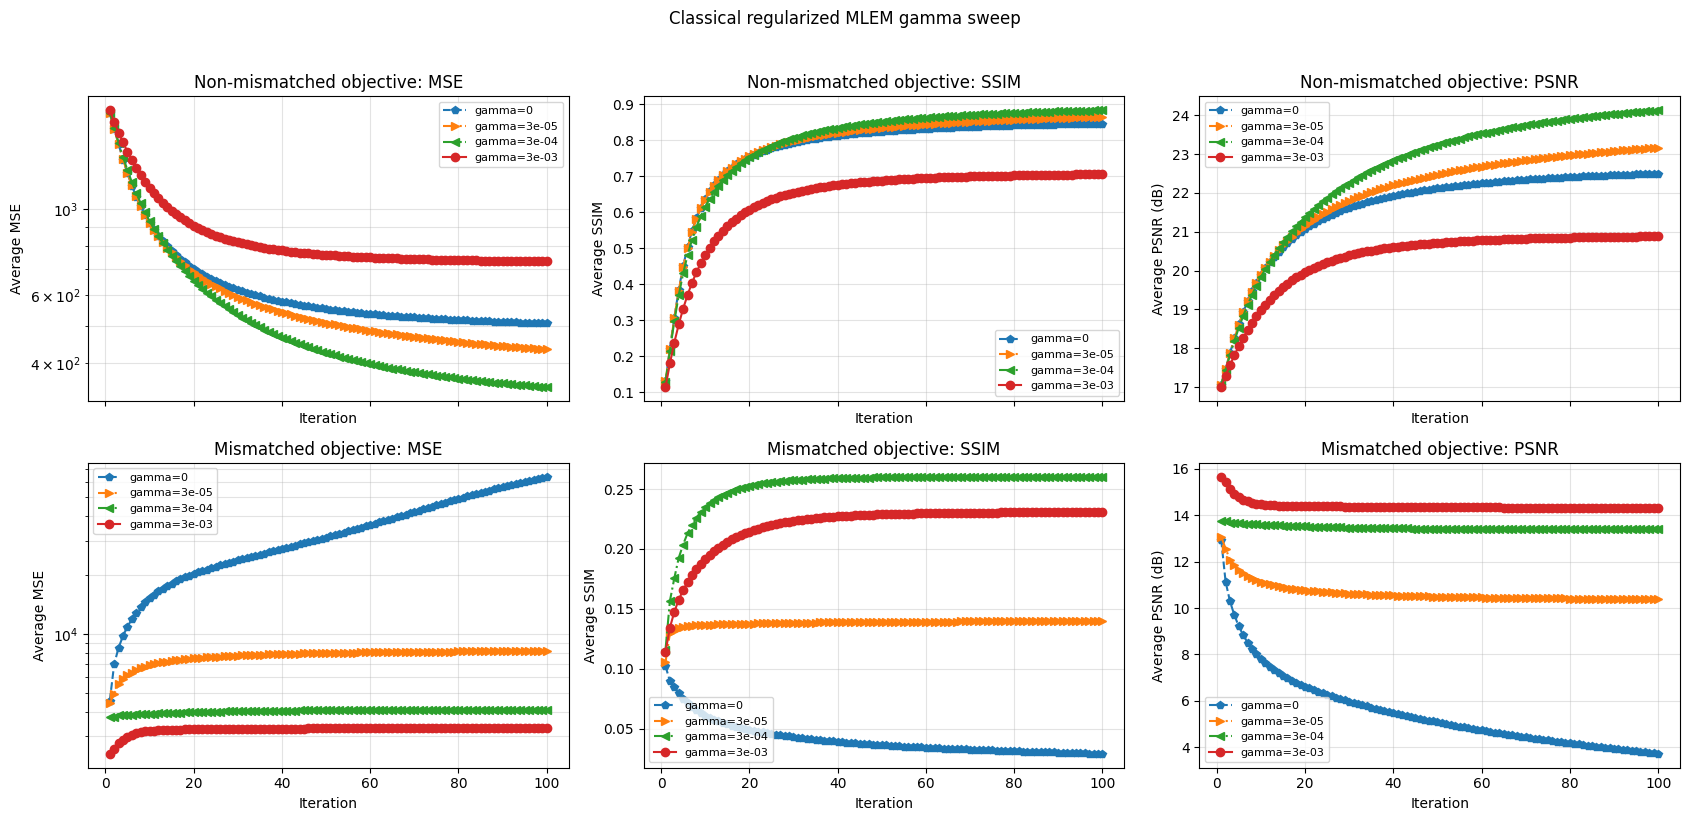

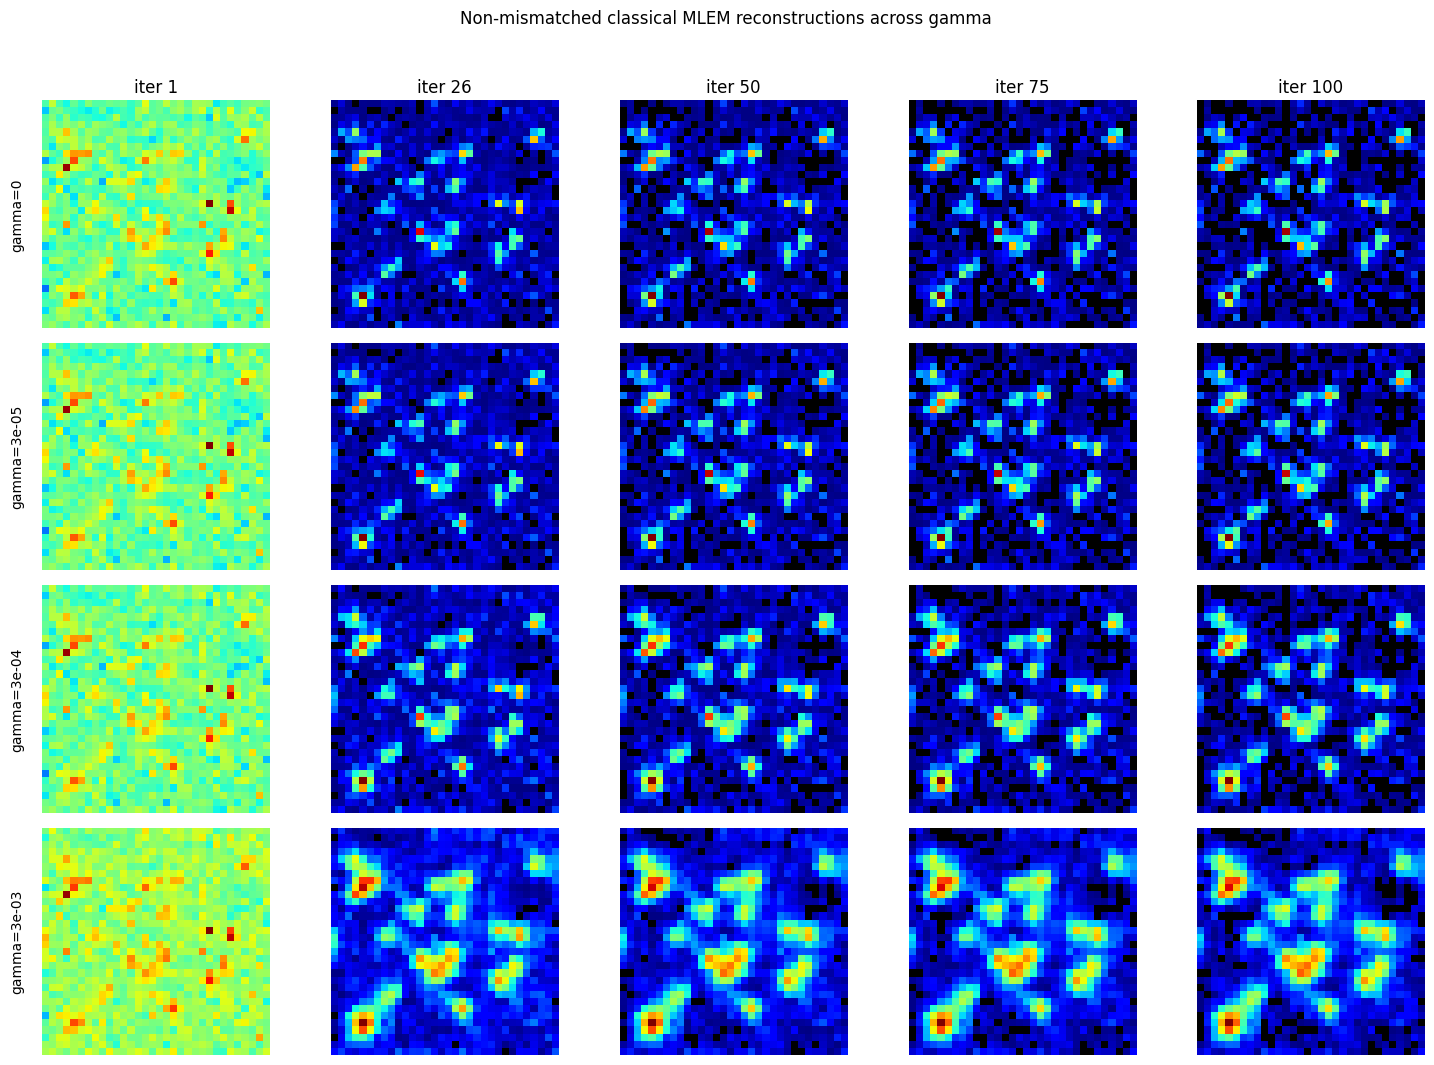

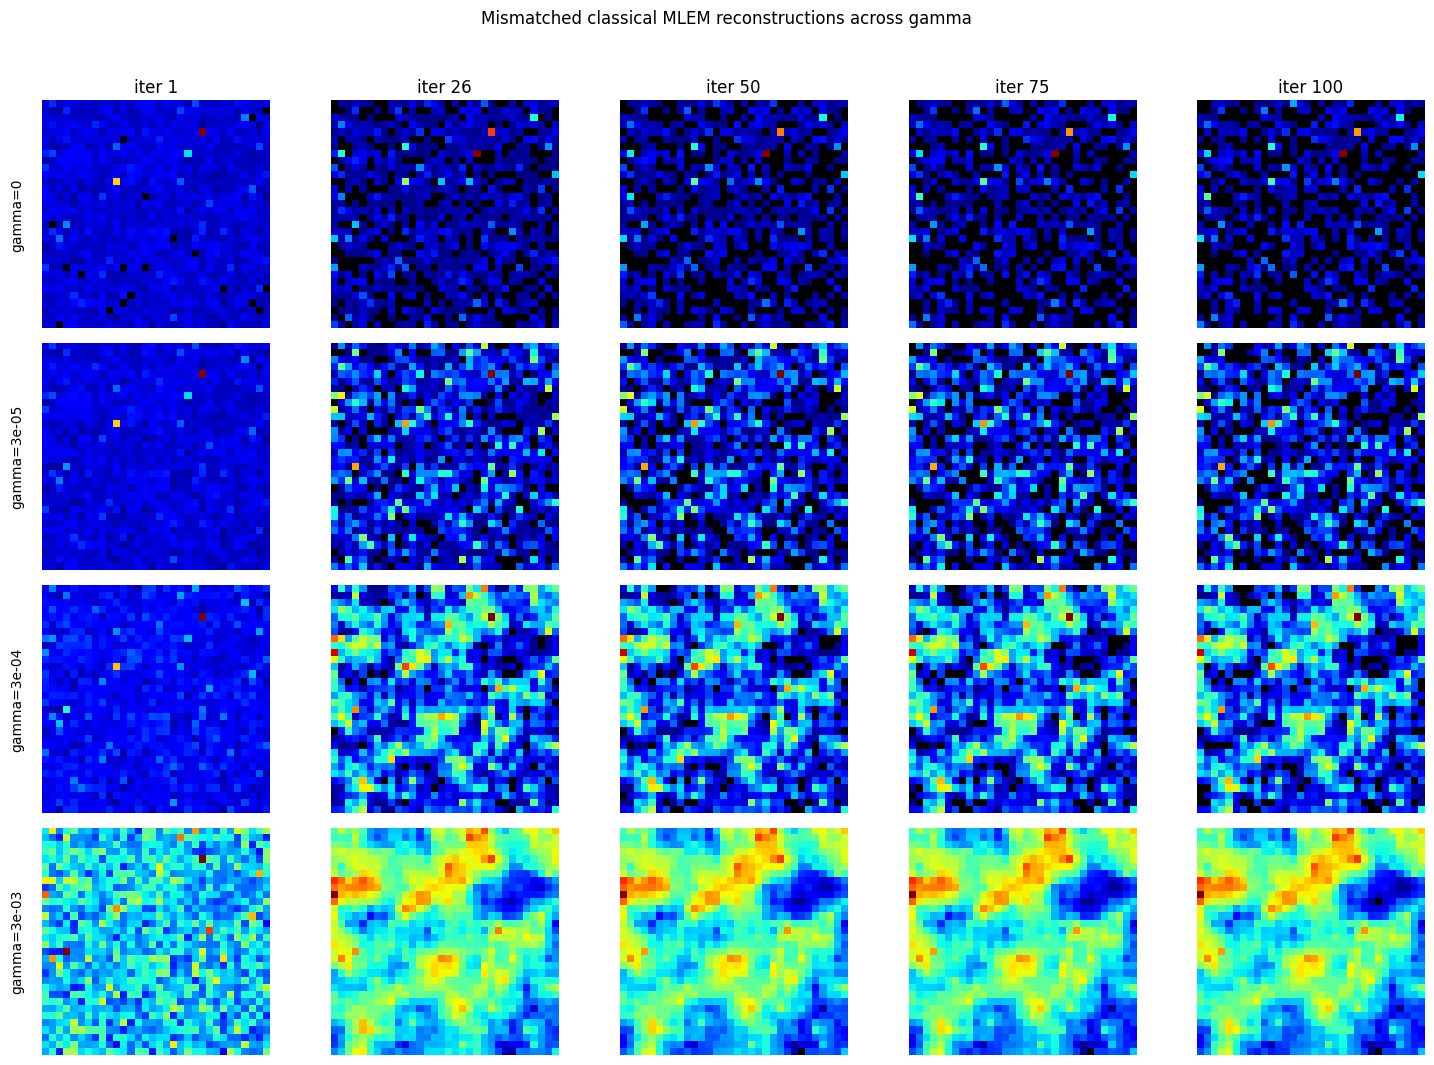

In [99]:
# ================================================================
# Gamma sweep study for classical regularized MLEM
# ================================================================
# This cell studies how the hand tuned regularization strength gamma affects
# classical EM reconstruction metrics under both matched and mismatched objectives.

run_gamma_sweep_study = True

gamma_sweep_values = np.array([0.0, 3e-5, 3e-4, 3e-3], dtype=np.float32)
gamma_sweep_num_runs = 50  # Number of independent run_regularized_mlem calls averaged per gamma/objective.
gamma_sweep_num_iters = config.num_mlem_iters


def format_gamma_label(gamma):
    """Compact gamma label for legends."""
    gamma = float(gamma)
    return "0" if gamma == 0.0 else f"{gamma:.0e}"


def global_ssim_numpy(x_hat, x_true, eps=1e-8):
    """Global SSIM-like score matching the lightweight tensor metric used elsewhere."""
    x_hat = np.asarray(x_hat, dtype=np.float64).reshape(-1)
    x_true = np.asarray(x_true, dtype=np.float64).reshape(-1)
    data_range = max(float(x_true.max() - x_true.min()), eps)
    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    mu_x = float(x_hat.mean())
    mu_y = float(x_true.mean())
    var_x = float(((x_hat - mu_x) ** 2).mean())
    var_y = float(((x_true - mu_y) ** 2).mean())
    cov_xy = float(((x_hat - mu_x) * (x_true - mu_y)).mean())
    return ((2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2) + eps)


def reconstruction_metrics_numpy(x_hat, x_true, eps=1e-8):
    """Compute MSE, SSIM, and PSNR for one reconstruction."""
    x_hat = np.asarray(x_hat, dtype=np.float64).reshape(-1)
    x_true = np.asarray(x_true, dtype=np.float64).reshape(-1)
    mse = float(np.mean((x_hat - x_true) ** 2))
    peak = max(float(x_true.max()), eps)
    psnr = 20.0 * np.log10(peak / np.sqrt(max(mse, eps)))
    ssim = global_ssim_numpy(x_hat, x_true, eps=eps)
    return {"MSE": mse, "SSIM": ssim, "PSNR": float(psnr)}


def evaluate_classical_mlem_gamma_sweep(A_recon, b_recon, raw_dataset, gamma_values, config, num_iters, num_mlem_runs=50):
    """
    Run classical regularized MLEM for several gamma values and average metrics by iteration.

    For each gamma value, the reported curve is the average over num_mlem_runs
    independent calls to run_regularized_mlem, each using one generated probe sample.
    """
    curves = {}
    X_true_all = raw_dataset["X"]
    Y_all = raw_dataset["Y"]
    available_runs = X_true_all.shape[0]
    if available_runs < num_mlem_runs:
        raise ValueError(f"Need at least {num_mlem_runs} probe samples, got {available_runs}.")

    for gamma in gamma_values:
        metric_sums = {
            "MSE": np.zeros(num_iters, dtype=np.float64),
            "SSIM": np.zeros(num_iters, dtype=np.float64),
            "PSNR": np.zeros(num_iters, dtype=np.float64),
        }

        for run_idx in range(num_mlem_runs):
            result = run_regularized_mlem(
                A_recon,
                Y_all[run_idx],
                b_recon,
                gamma=float(gamma),
                num_iters=num_iters,
                img_size=config.img_size,
                x0=None,
                eps=config.eps,
                x_true=X_true_all[run_idx],
            )
            # result["recons"] contains x0 followed by reconstructions after iterations 1..num_iters.
            for iter_idx, x_hat in enumerate(result["recons"][1:]):
                metrics = reconstruction_metrics_numpy(x_hat, X_true_all[run_idx], eps=config.eps)
                for metric_name in metric_sums:
                    metric_sums[metric_name][iter_idx] += metrics[metric_name]

        curves[float(gamma)] = {
            "step": np.arange(1, num_iters + 1),
            "num_mlem_runs": num_mlem_runs,
            "MSE": metric_sums["MSE"] / num_mlem_runs,
            "SSIM": metric_sums["SSIM"] / num_mlem_runs,
            "PSNR": metric_sums["PSNR"] / num_mlem_runs,
        }
    return curves


def plot_classical_gamma_sweep(non_mismatch_curves, mismatch_curves):
    """Plot a 2x3 grid: metrics by iteration for several gamma values and both objective settings."""
    cases = [
        ("Non-mismatched objective", non_mismatch_curves),
        ("Mismatched objective", mismatch_curves),
    ]
    metrics = [
        ("MSE", "Average MSE", True),
        ("SSIM", "Average SSIM", False),
        ("PSNR", "Average PSNR (dB)", False),
    ]
    styles = ["--p", "-.>", "-.<", "-o", "--v", "-s", ":d"]

    fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex=True)
    for row_idx, (case_title, curves) in enumerate(cases):
        for col_idx, (metric_name, ylabel, use_log_y) in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            max_step = 0
            for gamma_idx, (gamma, curve) in enumerate(curves.items()):
                steps = curve["step"]
                values = curve[metric_name]
                max_step = max(max_step, int(np.max(steps)))
                label = f"gamma={format_gamma_label(gamma)}"
                style = styles[gamma_idx % len(styles)]
                if use_log_y:
                    ax.semilogy(steps, values, style, label=label)
                else:
                    ax.plot(steps, values, style, label=label)
            ax.set_title(f"{case_title}: {metric_name}")
            ax.set_xlabel("Iteration")
            ax.set_ylabel(ylabel)
            if max_step > 0 and max_step <= 20:
                ax.set_xticks(np.arange(1, max_step + 1))
            ax.grid(True, which="both", alpha=0.35)
            ax.legend(fontsize=8)

    fig.suptitle("Classical regularized MLEM gamma sweep", y=1.02)
    fig.tight_layout()
    plt.show()


def select_gamma_sweep_display_iterations(num_iters, num_panels=5):
    """Pick exactly num_panels EM iterations for gamma reconstruction image grids."""
    if num_iters < 1:
        raise ValueError("num_iters must be at least 1 for reconstruction image plots.")
    return np.clip(
        np.rint(np.linspace(1, num_iters, num_panels)).astype(int),
        1,
        num_iters,
    )


def plot_gamma_sweep_reconstruction_grid(
    A_recon,
    b_recon,
    raw_dataset,
    gamma_values,
    config,
    num_iters,
    title,
    sample_idx=0,
    num_panels=5,
):
    """Plot len(gamma_values) x num_panels EM reconstructions across gamma and iteration."""
    if len(gamma_values) == 0:
        return
    if raw_dataset["X"].shape[0] == 0:
        raise ValueError("raw_dataset must contain at least one sample for reconstruction image plots.")
    if not 0 <= sample_idx < raw_dataset["X"].shape[0]:
        raise ValueError(f"sample_idx={sample_idx} is outside the available gamma sweep samples.")

    iteration_numbers = select_gamma_sweep_display_iterations(num_iters, num_panels=num_panels)
    x_true = raw_dataset["X"][sample_idx]
    y = raw_dataset["Y"][sample_idx]

    fig, axes = plt.subplots(
        len(gamma_values),
        num_panels,
        figsize=(3.0 * num_panels, 2.6 * len(gamma_values)),
        squeeze=False,
    )

    for row_idx, gamma in enumerate(gamma_values):
        result = run_regularized_mlem(
            A_recon,
            y,
            b_recon,
            gamma=float(gamma),
            num_iters=num_iters,
            img_size=config.img_size,
            x0=None,
            eps=config.eps,
            x_true=x_true,
        )
        for col_idx, iter_num in enumerate(iteration_numbers):
            ax = axes[row_idx, col_idx]
            show_image_vector(result["recons"][iter_num], config.img_size, ax=ax)
            if row_idx == 0:
                ax.set_title(f"iter {iter_num}")
            if col_idx == 0:
                ax.text(
                    -0.08,
                    0.5,
                    f"gamma={format_gamma_label(gamma)}",
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="right",
                    fontsize=10,
                    clip_on=False,
                )

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


if run_gamma_sweep_study:
    print("Running classical MLEM gamma sweep...")
    print("gamma values:", [format_gamma_label(g) for g in gamma_sweep_values])
    print("MLEM runs averaged per gamma/objective:", gamma_sweep_num_runs, "iterations:", gamma_sweep_num_iters)

    rng_gamma_sweep = np.random.default_rng(config.seed + 700)
    _, gamma_sweep_raw = generate_reconstruction_dataset(
        A_true,
        b_true,
        config,
        gamma_sweep_num_runs,
        rng_gamma_sweep,
    )

    A_nominal_gamma_sweep, b_nominal_gamma_sweep = create_mismatched_nominal_model(
        A_true,
        b_true,
        config,
        np.random.default_rng(config.seed + 701),
    )

    gamma_sweep_non_mismatched = evaluate_classical_mlem_gamma_sweep(
        A_true,
        b_true,
        gamma_sweep_raw,
        gamma_sweep_values,
        config,
        gamma_sweep_num_iters,
        num_mlem_runs=gamma_sweep_num_runs,
    )
    gamma_sweep_mismatched = evaluate_classical_mlem_gamma_sweep(
        A_nominal_gamma_sweep,
        b_nominal_gamma_sweep,
        gamma_sweep_raw,
        gamma_sweep_values,
        config,
        gamma_sweep_num_iters,
        num_mlem_runs=gamma_sweep_num_runs,
    )

    plot_classical_gamma_sweep(gamma_sweep_non_mismatched, gamma_sweep_mismatched)

    plot_gamma_sweep_reconstruction_grid(
        A_true,
        b_true,
        gamma_sweep_raw,
        gamma_sweep_values,
        config,
        gamma_sweep_num_iters,
        title="Non-mismatched classical MLEM reconstructions across gamma",
    )
    plot_gamma_sweep_reconstruction_grid(
        A_nominal_gamma_sweep,
        b_nominal_gamma_sweep,
        gamma_sweep_raw,
        gamma_sweep_values,
        config,
        gamma_sweep_num_iters,
        title="Mismatched classical MLEM reconstructions across gamma",
    )
else:
    print("Gamma sweep skipped. Set run_gamma_sweep_study=True to run it.")



# Experiment 1: Non Mismatched Objective

Here the same model is used for data generation and reconstruction:

```python
A_train = A_true
b_train = b_true
A_eval = A_true
b_eval = b_true
```

The main comparison asks whether learned hyperparameters or a learned denominator correction improve over the hand tuned regularized MLEM baseline when the assumed objective is correct.


In [100]:
if config.run_non_mismatched_experiment:
    config = replace(config, EXPERIMENT_NAME="non_mismatched")
    EXPERIMENT_NAME = "non_mismatched"
    A_recon_non_mismatched = A_true.copy()
    b_recon_non_mismatched = b_true.copy()

    rng_exp1 = np.random.default_rng(config.seed + 100)
    (train_dataset_nm, val_dataset_nm, test_dataset_nm), raw_nm = create_train_val_test_datasets(
        A_true, b_true, config, rng_exp1
    )
    print("Experiment 1 datasets:", len(train_dataset_nm), len(val_dataset_nm), len(test_dataset_nm))
    print("A_recon is A_true:", A_recon_non_mismatched.shape == A_true.shape)
else:
    print("Experiment 1 skipped by configuration.")


Experiment 1 datasets: 2500 500 100
A_recon is A_true: True



===== non_mismatched =====
Training reconstruction loss: Frobenius norm

--- classical_regularized ---
  learnable parameters: 0
  non-trainable model; skipping training

--- learned_gamma ---
  learnable parameters: 10
  Layer-wise training: seq enables only current layer; e2e enables layers up to current depth
Layer 0, Seq-training ======================
  seq layer 00 active_layers=01 epoch 001: train=1.3372e+03, val=1.3328e+03
  seq layer 00 active_layers=01 epoch 010: train=1.3371e+03, val=1.3327e+03
  seq layer 00 active_layers=01 epoch 020: train=1.3370e+03, val=1.3326e+03
  seq layer 00 active_layers=01 epoch 030: train=1.3370e+03, val=1.3325e+03
  seq layer 00 active_layers=01 epoch 040: train=1.3369e+03, val=1.3325e+03
  seq layer 00 active_layers=01 epoch 050: train=1.3369e+03, val=1.3325e+03
Layer 1, Seq-training ======================
  seq layer 01 active_layers=02 epoch 001: train=1.2781e+03, val=1.2737e+03
  seq layer 01 active_layers=02 epoch 010: train=1.2779e+03, va

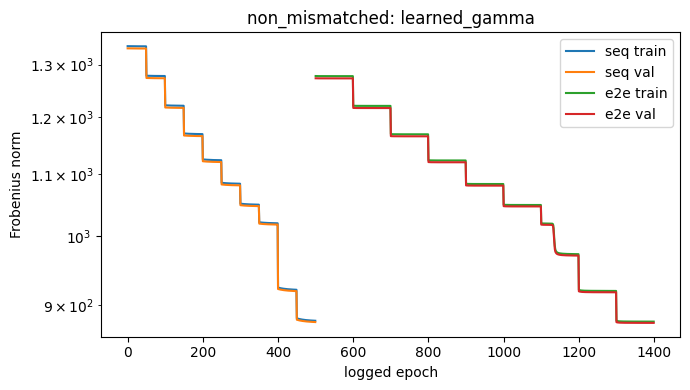

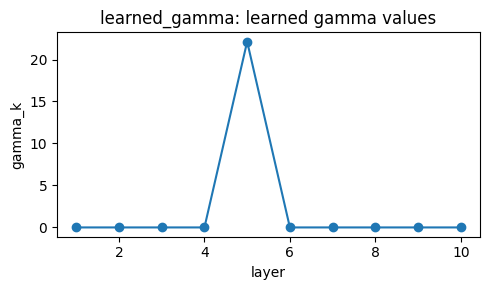


--- denominator_correction ---
  learnable parameters: 3,700
  Layer-wise training: seq enables only current layer; e2e enables layers up to current depth
Layer 0, Seq-training ======================
  seq layer 00 active_layers=01 epoch 001: train=1.3372e+03, val=1.3326e+03
  seq layer 00 active_layers=01 epoch 010: train=1.3329e+03, val=1.3282e+03
  seq layer 00 active_layers=01 epoch 020: train=1.3273e+03, val=1.3225e+03
  seq layer 00 active_layers=01 epoch 030: train=1.3222e+03, val=1.3174e+03
  seq layer 00 active_layers=01 epoch 040: train=1.3179e+03, val=1.3131e+03
  seq layer 00 active_layers=01 epoch 050: train=1.3138e+03, val=1.3090e+03
Layer 1, Seq-training ======================
  seq layer 01 active_layers=02 epoch 001: train=1.2371e+03, val=1.2325e+03
  seq layer 01 active_layers=02 epoch 010: train=1.2314e+03, val=1.2249e+03
  seq layer 01 active_layers=02 epoch 020: train=1.2185e+03, val=1.2135e+03
  seq layer 01 active_layers=02 epoch 030: train=1.2117e+03, val=1.206

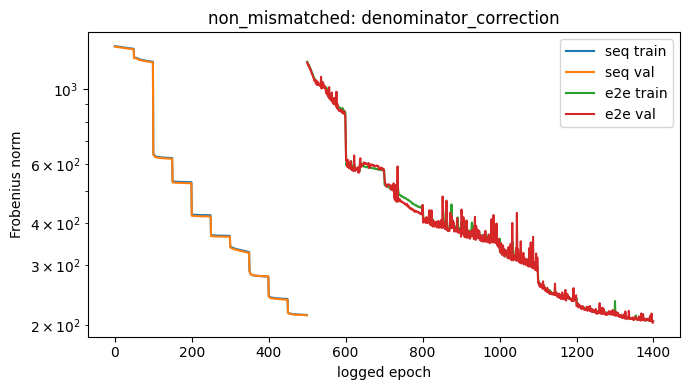

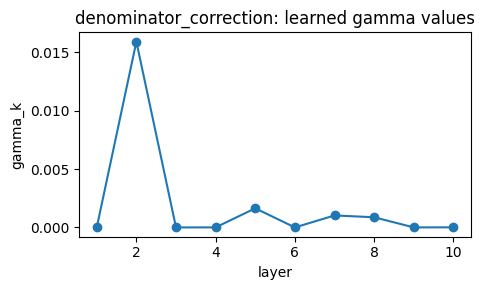

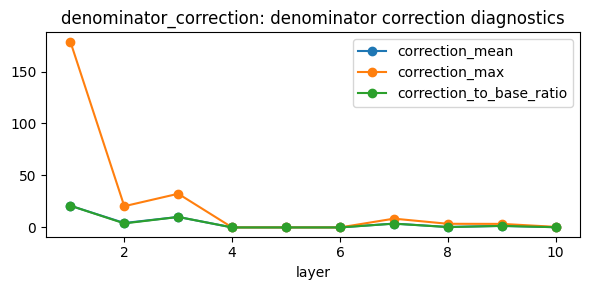

,experiment,model,MSE,PSNR,SSIM,relative_error,total_count_error,NLL_true,NLL_recon,NLL_learned,R(x),objective_recon,objective_learned,layers_or_iters
0,non_mismatched,classical_regularized,365.002075,24.222031,0.881613,0.400059,0.008338,-57171.957031,-57171.957031,NaN,846409.75000,-57087.320312,NaN,100
1,non_mismatched,learned_gamma,745.815308,21.114550,0.693766,0.571139,0.000333,-56717.734375,-56717.734375,NaN,346923.34375,711054.812500,NaN,10
2,non_mismatched,denominator_correction,40.969334,33.778957,0.988939,0.133506,0.024293,-57035.507812,-57035.507812,NaN,922438.37500,-55240.417969,NaN,10


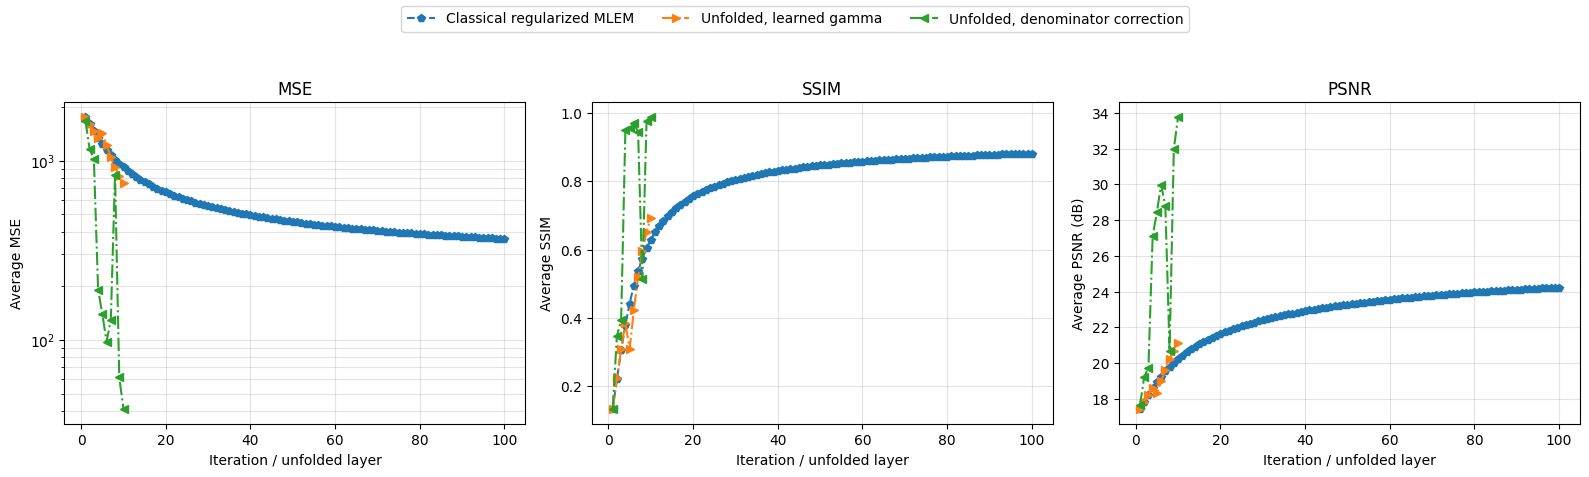

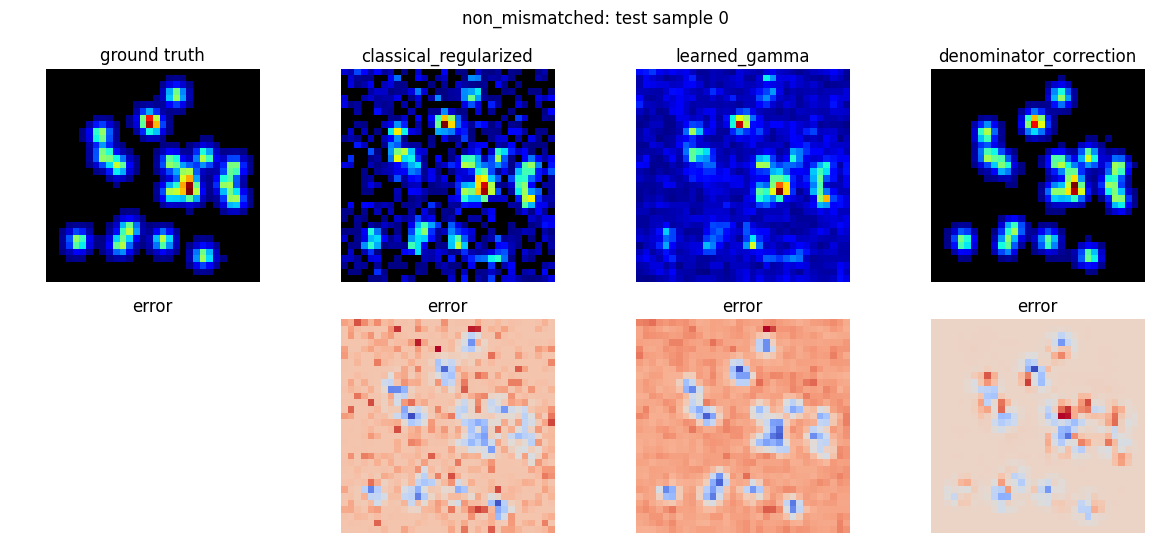

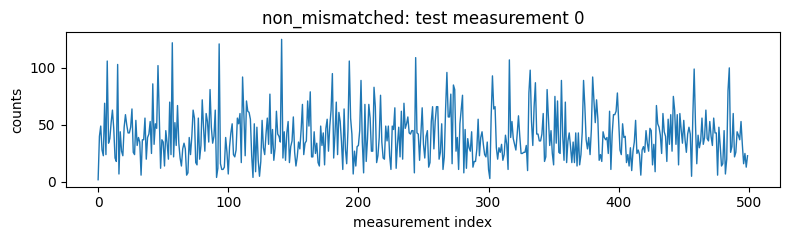

In [101]:
results_non_mismatched = None
if config.run_non_mismatched_experiment:
    results_non_mismatched = run_experiment(
        "non_mismatched",
        A_true,
        b_true,
        A_recon_non_mismatched,
        b_recon_non_mismatched,
        train_dataset_nm,
        val_dataset_nm,
        test_dataset_nm,
        config,
    )


# Experiment 2: Mismatched Objective

Data are still generated from `A_true, b_true`, but the classical and non-objective learned models reconstruct with a mismatched nominal objective:

```python
y ~ Poisson(A_true x + b_true)
A_recon = A_nominal
b_recon = b_nominal
```

The learned objective model is included as a core model and initialized from `A_nominal, b_nominal`.


In [102]:
if config.run_mismatched_experiment:
    config = replace(config, EXPERIMENT_NAME="mismatched")
    EXPERIMENT_NAME = "mismatched"
    rng_mismatch = np.random.default_rng(config.seed + 200)
    A_nominal, b_nominal = create_mismatched_nominal_model(A_true, b_true, config, rng_mismatch)
    A_recon_mismatched = A_nominal
    b_recon_mismatched = b_nominal

    rng_exp2 = np.random.default_rng(config.seed + 300)
    (train_dataset_mis, val_dataset_mis, test_dataset_mis), raw_mis = create_train_val_test_datasets(
        A_true, b_true, config, rng_exp2
    )

    print("Experiment 2 datasets:", len(train_dataset_mis), len(val_dataset_mis), len(test_dataset_mis))
    print("A_true nnz:", A_true.nnz, "A_nominal nnz:", A_nominal.nnz)
    print("b_true range:", (float(b_true.min()), float(b_true.max())))
    print("b_nominal range:", (float(b_nominal.min()), float(b_nominal.max())))
else:
    print("Experiment 2 skipped by configuration.")


Experiment 2 datasets: 2500 500 100
A_true nnz: 14927 A_nominal nnz: 4387
b_true range: (0.25, 0.25)
b_nominal range: (0.2750000059604645, 0.2750000059604645)



===== mismatched =====
Training reconstruction loss: Frobenius norm

--- classical_regularized ---
  learnable parameters: 0
  non-trainable model; skipping training

--- learned_gamma ---
  learnable parameters: 10
  Layer-wise training: seq enables only current layer; e2e enables layers up to current depth
Layer 0, Seq-training ======================
  seq layer 00 active_layers=01 epoch 001: train=1.9980e+03, val=1.9966e+03
  seq layer 00 active_layers=01 epoch 010: train=1.9801e+03, val=1.9783e+03
  seq layer 00 active_layers=01 epoch 020: train=1.9537e+03, val=1.9514e+03
  seq layer 00 active_layers=01 epoch 030: train=1.9189e+03, val=1.9160e+03
  seq layer 00 active_layers=01 epoch 040: train=1.8744e+03, val=1.8708e+03
  seq layer 00 active_layers=01 epoch 050: train=1.8196e+03, val=1.8153e+03
Layer 1, Seq-training ======================
  seq layer 01 active_layers=02 epoch 001: train=2.0717e+03, val=2.0702e+03
  seq layer 01 active_layers=02 epoch 010: train=2.0365e+03, val=2.

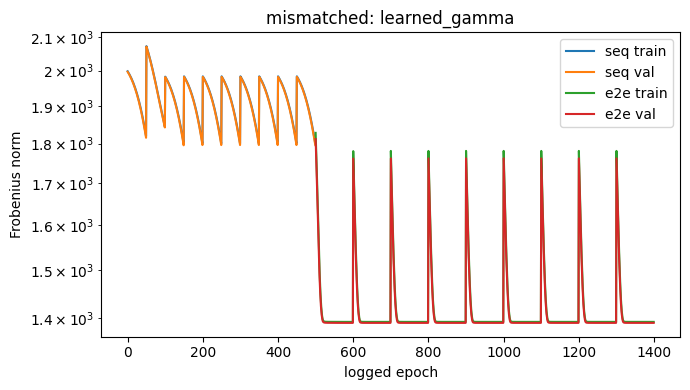

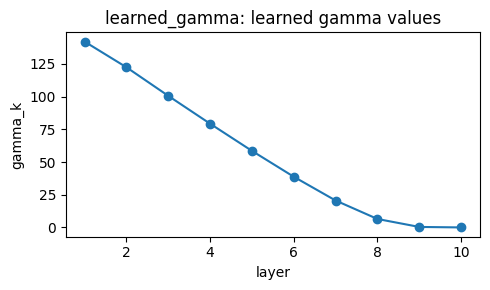


--- denominator_correction ---
  learnable parameters: 3,700
  Layer-wise training: seq enables only current layer; e2e enables layers up to current depth
Layer 0, Seq-training ======================
  seq layer 00 active_layers=01 epoch 001: train=1.7939e+03, val=1.5277e+03
  seq layer 00 active_layers=01 epoch 010: train=1.3624e+03, val=1.3565e+03
  seq layer 00 active_layers=01 epoch 020: train=1.3215e+03, val=1.3183e+03
  seq layer 00 active_layers=01 epoch 030: train=1.3016e+03, val=1.2988e+03
  seq layer 00 active_layers=01 epoch 040: train=1.2902e+03, val=1.2877e+03
  seq layer 00 active_layers=01 epoch 050: train=1.2820e+03, val=1.2797e+03
Layer 1, Seq-training ======================
  seq layer 01 active_layers=02 epoch 001: train=1.6678e+03, val=1.4143e+03
  seq layer 01 active_layers=02 epoch 010: train=1.2949e+03, val=1.2912e+03
  seq layer 01 active_layers=02 epoch 020: train=1.2759e+03, val=1.2729e+03
  seq layer 01 active_layers=02 epoch 030: train=1.2623e+03, val=1.259

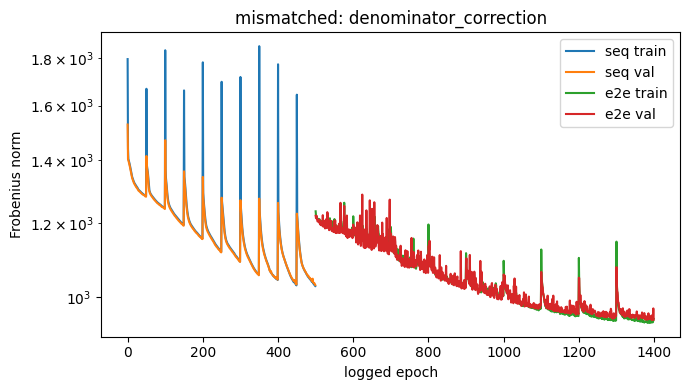

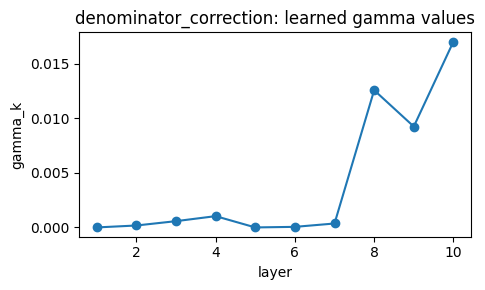

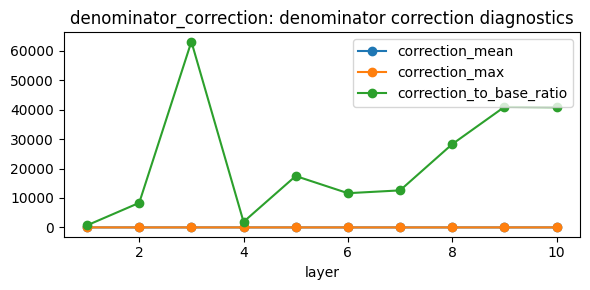


--- learned_objective ---
  learnable parameters: 512,510
  Layer-wise training: seq enables only current layer; e2e enables layers up to current depth
Layer 0, Seq-training ======================
  seq layer 00 active_layers=01 epoch 001: train=1.9774e+03, val=1.9537e+03
  seq layer 00 active_layers=01 epoch 010: train=1.6724e+03, val=1.6585e+03
  seq layer 00 active_layers=01 epoch 020: train=1.4927e+03, val=1.4849e+03
  seq layer 00 active_layers=01 epoch 030: train=1.4057e+03, val=1.4016e+03
  seq layer 00 active_layers=01 epoch 040: train=1.3733e+03, val=1.3708e+03
  seq layer 00 active_layers=01 epoch 050: train=1.3579e+03, val=1.3560e+03
Layer 1, Seq-training ======================
  seq layer 01 active_layers=02 epoch 001: train=1.3526e+03, val=1.3501e+03
  seq layer 01 active_layers=02 epoch 010: train=1.3273e+03, val=1.3262e+03
  seq layer 01 active_layers=02 epoch 020: train=1.3120e+03, val=1.3115e+03
  seq layer 01 active_layers=02 epoch 030: train=1.3017e+03, val=1.3015e+

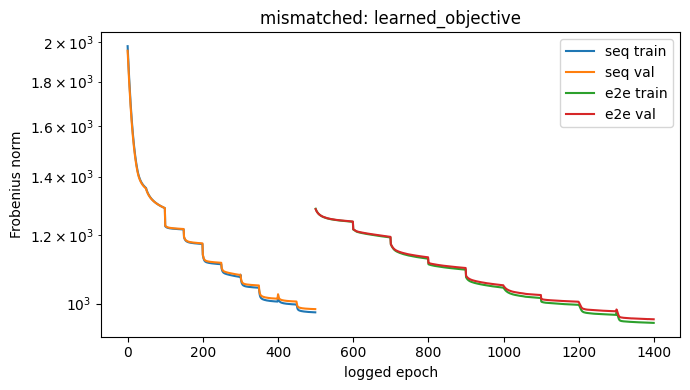

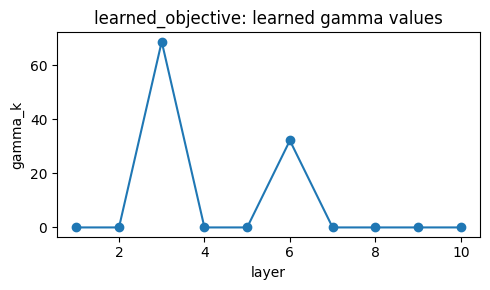

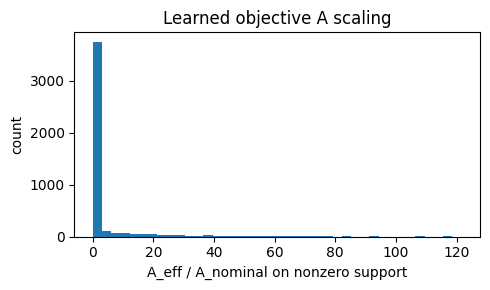

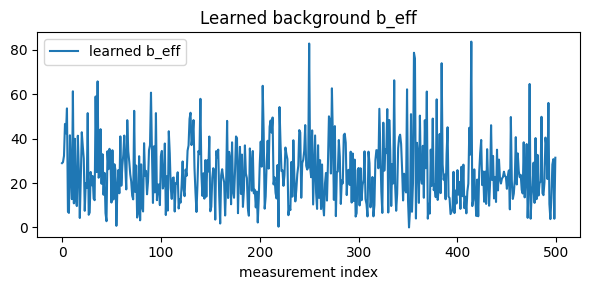

  learned objective relative A change: 1.0006e+01
  learned objective relative b change: 1.0481e+02


,experiment,model,MSE,PSNR,SSIM,relative_error,total_count_error,NLL_true,NLL_recon,NLL_learned,R(x),objective_recon,objective_learned,layers_or_iters
0,mismatched,classical_regularized,5489.986816,12.205612,0.210939,1.557311,0.045486,-34299.843750,-56658.152344,NaN,4.554554e+06,-5.620270e+04,NaN,100
1,mismatched,learned_gamma,1874.689697,16.887094,0.059469,0.907705,0.630175,-54575.910156,-46534.609375,NaN,8.763085e+03,4.520590e+05,NaN,10
2,mismatched,denominator_correction,888.360107,20.158865,0.690828,0.624632,0.695065,-56169.796875,-43530.390625,NaN,3.316158e+05,-4.217111e+04,NaN,10
3,mismatched,learned_objective,911.301208,20.027386,0.662597,0.633636,0.637210,-55831.179688,-46040.750000,-51727.917969,3.648660e+05,3.630736e+06,3625049.0,10


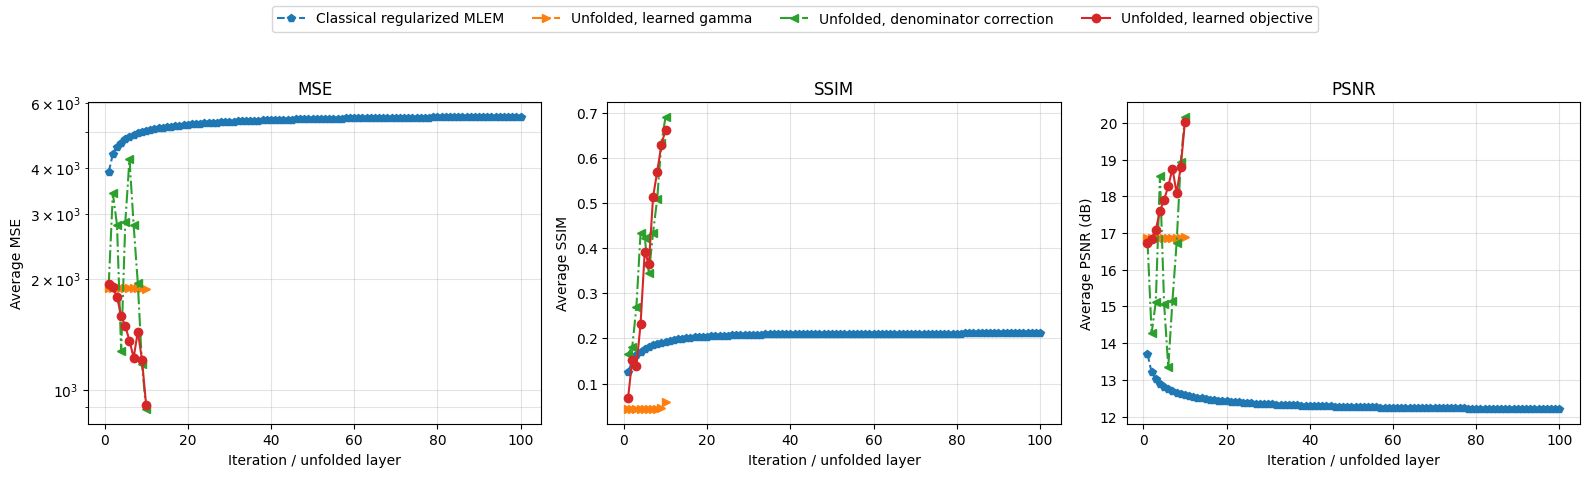

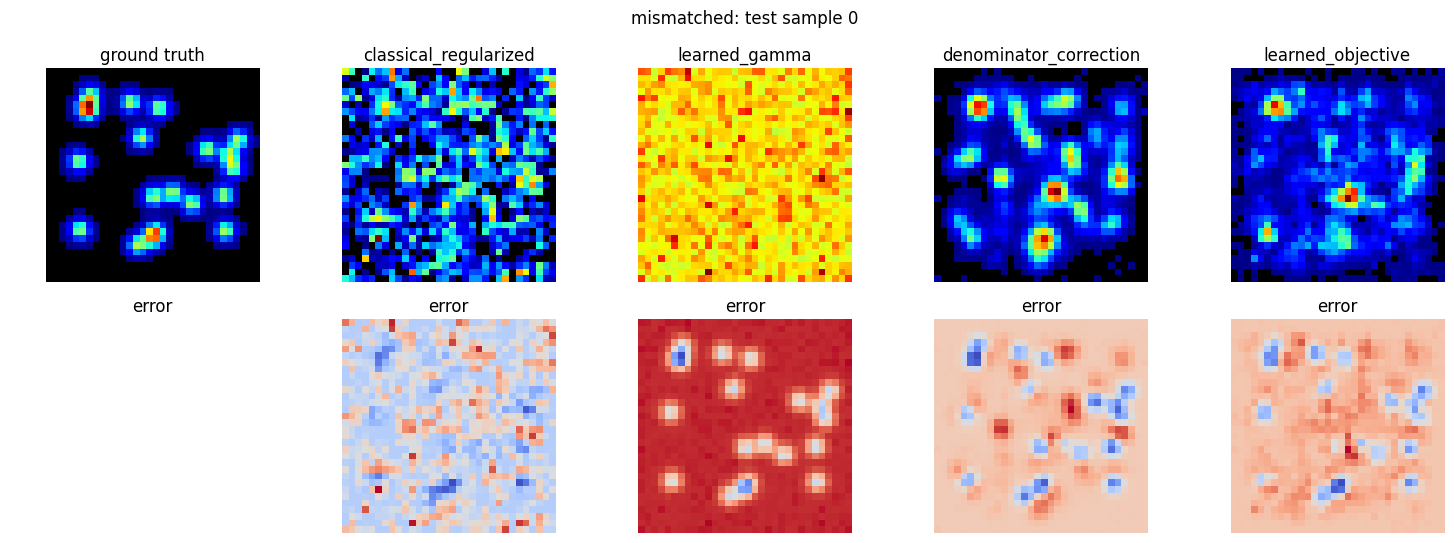

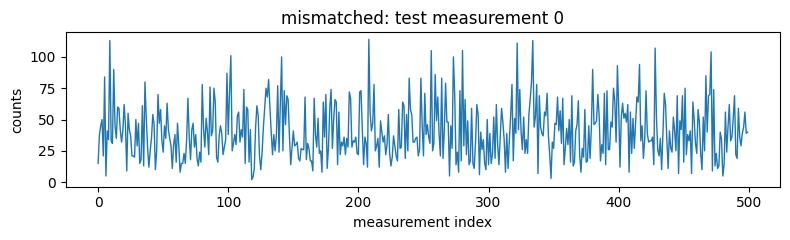

In [103]:
results_mismatched = None
if config.run_mismatched_experiment:
    results_mismatched = run_experiment(
        "mismatched",
        A_true,
        b_true,
        A_recon_mismatched,
        b_recon_mismatched,
        train_dataset_mis,
        val_dataset_mis,
        test_dataset_mis,
        config,
    )


## Cross Experiment Summary Table


In [104]:
all_rows = []
if results_non_mismatched is not None:
    all_rows.extend(results_non_mismatched["rows"])
if results_mismatched is not None:
    all_rows.extend(results_mismatched["rows"])

if all_rows:
    cross_experiment_table = display_comparison_table(all_rows)
else:
    print("No experiment rows available.")


,experiment,model,MSE,PSNR,SSIM,relative_error,total_count_error,NLL_true,NLL_recon,NLL_learned,R(x),objective_recon,objective_learned,layers_or_iters
0,non_mismatched,classical_regularized,365.002075,24.222031,0.881613,0.400059,0.008338,-57171.957031,-57171.957031,NaN,8.464098e+05,-5.708732e+04,NaN,100
1,non_mismatched,learned_gamma,745.815308,21.114550,0.693766,0.571139,0.000333,-56717.734375,-56717.734375,NaN,3.469233e+05,7.110548e+05,NaN,10
2,non_mismatched,denominator_correction,40.969334,33.778957,0.988939,0.133506,0.024293,-57035.507812,-57035.507812,NaN,9.224384e+05,-5.524042e+04,NaN,10
3,mismatched,classical_regularized,5489.986816,12.205612,0.210939,1.557311,0.045486,-34299.843750,-56658.152344,NaN,4.554554e+06,-5.620270e+04,NaN,100
4,mismatched,learned_gamma,1874.689697,16.887094,0.059469,0.907705,0.630175,-54575.910156,-46534.609375,NaN,8.763085e+03,4.520590e+05,NaN,10
5,mismatched,denominator_correction,888.360107,20.158865,0.690828,0.624632,0.695065,-56169.796875,-43530.390625,NaN,3.316158e+05,-4.217111e+04,NaN,10
6,mismatched,learned_objective,911.301208,20.027386,0.662597,0.633636,0.637210,-55831.179688,-46040.750000,-51727.917969,3.648660e+05,3.630736e+06,3625049.0,10


## Notes for Future Extensions

- Replace dense torch matrix products with sparse torch kernels for larger systems.
- Add sample-dependent or structured background vectors.
- Tune the denominator correction features or make the correction network layer-specific.
- Add unsupervised or hybrid losses based directly on the Poisson objective.
- Replace the simple global SSIM-like score with a windowed image SSIM metric when `scikit-image` is available.
